# 🇨🇴 v2.3 — Series de Tiempo + Áreas Operativas del SIN

**Proyecto:** Energy Data Analysis Portfolio — Solar Generation Colombia   
**Notebook:** `02_serie_tiempo_balance_v2.ipynb`  
**Prerequisito:** Realizar la ejecución de forma previa del notebook `01_ETL_exploracion_v1.ipynb` (datos se almacenan en `data/raw/`)  
**Autor:** Manuel Fernando Fajardo Rodríguez

---

## 🎯 Objetivo

Extender el análisis de los datos obtenidos de la v1 integrando **demanda real**, **precio de bolsa**, **nivel de embalses** y **aportes hídricos** para construir una visión completa del **balance energético del SIN** durante el período analizado. Este notebook queda además como la base de datos limpios que consumirá v2.5 (caso SAEB — Resolución CREG 101-113 de 2026).

### Preguntas que responde este notebook

1. **¿Cuál es el balance horario generación–demanda?** → ¿Hay excedentes o déficit? ¿A qué horas?
2. **¿Cómo responde el precio de bolsa a la composición de la generación?** → Correlación con participación térmica y nivel de embalses.
3. **¿Cuál es el estado de seguridad hídrica del sistema?** → Nivel de embalses, aportes, zonas de alerta.
4. **¿Existe una ventana de arbitraje para almacenamiento?** → Diferencial de precios pico/valle (input directo a v2.5 SAEB).

### Nuevas métricas de la API XM incorporadas

| MetricId | Nivel | Unidad | Descripción |
|:---------|:------|:-------|:------------|
| `DemaReal` | Sistema | kWh | Demanda real horaria del SIN |
| `PrecBolsNaci` | Sistema | COP/kWh | Precio de bolsa nacional horario |
| `PorcVoluUtilDiar` | Sistema | % | Nivel de embalses (% capacidad útil) |
| `AporEner` | Sistema | kWh | Aportes de energía hídrica al sistema |
| `PrecEsca` | Sistema | COP/kWh | Precio de escasez (umbral regulatorio) |

---

## 📂 Estructura del Repositorio

```
solar-generation-colombia/
├── notebooks/
│   └── 01_ETL_exploracion_v1.ipynb       ← Notebook proyecto v1
│   ├── 02_serie_tiempo_balance_v2.ipynb  ← Notebook proyecto v2
├── src/
│   ├── extraccion.py                      # Funciones de descarga desde la API XM
│   ├── etl.py                             # Pipeline de transformación (wide → long)
│   └── visualizaciones.py                 # Funciones de gráficos reutilizables
├── data/
│   ├── raw/                               # Datos crudos con estampa YYYYMMDD
│   │   ├── datos_generacion_YYYYMMDD.csv
│   │   ├── dim_plantas_YYYYMMDD.csv
│   │   ├── dim_agentes_YYYYMMDD.csv
│   │   └── dim_rios_YYYYMMDD.csv
│   └── processed/                         # Outputs limpios del ETL
│       ├── fact_generacion_YYYYMMDD.csv
│       ├── generacion_enriquecida_YYYYMMDD.csv
│       └── dim_plantas_clean_YYYYMMDD.csv
├── app/                                    # Dashboard Streamlit (v4 — futuro)
├── .gitignore
├── README.md
└── requirements.txt
```

---


## 📐 Arquitectura del notebook

La estructura inicial planteada para este notebook se divide de la siguiente forma:

```
Sección 0 — Configuración y dependencias
Sección 1 — Extracción multi-métrica (API XM → data/raw/)
Sección 2 — ETL: transformación al modelo analítico
Sección 3 — Balance generación–demanda
Sección 4 — Precio de bolsa y señales de mercado
Sección 5 — Contexto hídrico y seguridad del sistema
Sección 6 — Perfil horario consolidado (heatmaps)
Sección 7 — Resumen ejecutivo y preparación para v2.5 (SAEB)
```

> **Extensibilidad:** La Sección 7 deja preparado el análisis de arbitraje de precios para SAEB (Resolución CREG 101-113 de 2026), que será el foco de la v2.5.

> **Variante v2.1:** conserva el análisis v2 aprobado y añade figuras separadas, matriz triangular, mapa de burbujas, perfiles tecnológicos, selector geográfico opcional y comparación solar–demanda.
> **Variante v2.2:** conserva las mejoras visuales de v2.1 y sustituye la clasificación manual por una integración automática y auditable con las áreas y subáreas operativas oficiales de SIMEM.

> **Variante v2.3 definitiva:** compara la cobertura operativa de SIMEM con la capa geográfica pública UPME/XM, conserva ambos conceptos por separado y alcanza cobertura conjunta completa para las plantas del período analizado.

## ⚙️ Sección 0 — Configuración y dependencias

El notebook utiliza la libreria `pandas` para transformar datos, `numpy` para cálculos y
`matplotlib`/`seaborn` para gráficos publicables. Para el uso de la libreria de XM `pydataxm` solo es obligatorio
en los modos `API` y `FIJO`; el modo `CSV` permite reproducir los datos sin conexión directa a la API.

> **Reproducibilidad:** el período analítico es la intersección de fechas
> disponible en las métricas cargadas. Así se evita comparar series de ventanas
> distintas o completar silenciosamente días con datos de otro período.

In [1]:
# Si no se encuentran las librerías necesarias, descomentar la siguiente línea y ejecutar el script nuevamente
# %pip install pydataxm pandas numpy matplotlib seaborn openpyxl

In [2]:
# ── Librerías ────────────────────────────────────────────────────────────────
import datetime as dt
import glob
import os
import time
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests


warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Importación de IPython.display para mostrar tablas en Jupyter
try:
    from IPython.display import display
except ImportError:
    display = print

# pydataxm es opcional: solo se requiere para los modos API y FIJO
try:
    from pydataxm import pydataxm
    API_DISPONIBLE = True
    print("✅ pydataxm disponible — modos API/FIJO/CSV habilitados.")
except ImportError:
    API_DISPONIBLE = False
    print("⚠️  pydataxm no instalado — solo modo CSV disponible.")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


# ── Paletas de colores (consistente con v1) ──────────────────────────────────
COLORES_TECNO = {
    "HIDRAULICA":  "#2196F3",
    "SOLAR":       "#FFC107",
    "TERMICA":     "#F44336",
    "EOLICA":      "#4CAF50",
    "COGENERADOR": "#9C27B0",
}

COLORES_METRICA = {
    "generacion": "#2196F3",
    "demanda":    "#FF5722",
    "precio":     "#FFC107",
    "embalses":   "#00BCD4",
    "aportes":    "#8BC34A",
    "escasez":    "#B71C1C",
}

# Umbrales exploratorios configurables; no equivalen a gatillos regulatorios.
UMBRAL_EMBALSES_ALERTA = 60
UMBRAL_EMBALSES_CRITICO = 40

# Ventanas exploratorias para el puente hacia v2.5.
HORAS_PICO = (18, 22)
HORAS_VALLE = (1, 6)
EFICIENCIA_RT_SAEB = 0.87

print("\n✅ Configuración completa.")

✅ pydataxm disponible — modos API/FIJO/CSV habilitados.

✅ Configuración completa.


In [4]:
# ── Rutas del proyecto (auto-detección de la carpeta raíz asociada del proyecto) ───────────────────────────
def detectar_base_dir() -> Path:
    """Detecta la raíz del repositorio si se ejecuta desde notebooks/ o desde la raíz."""
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists() and (cwd / "notebooks").exists():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "data").exists():
        return cwd.parent
    return cwd.parent if (cwd.parent / "data").exists() else cwd


BASE_DIR      = detectar_base_dir()
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIG_DIR       = PROCESSED_DIR / "figuras_v2"

for d in (RAW_DIR, PROCESSED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"📁 BASE_DIR:      {BASE_DIR}")
print(f"📁 RAW_DIR:       {RAW_DIR}")
print(f"📁 PROCESSED_DIR: {PROCESSED_DIR}")
print(f"📁 FIG_DIR:       {FIG_DIR}")

📁 BASE_DIR:      G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash
📁 RAW_DIR:       G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\raw
📁 PROCESSED_DIR: G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\processed
📁 FIG_DIR:       G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\processed\figuras_v2


---
## 📥 Sección 1 — Extracción Multi-Métrica (API XM)

### 1.1 Funciones de extracción reutilizables

A diferencia de la v1 (la cual solo descargaba los datos de `Gene` por `Recurso`), mediante el uso de la v2 se requiere descargar **múltiples métricas a nivel Sistema**. Mediante el uso de las funciones `descargar_metrica()` y `clasificar_fechas()` se busca manejar:

- Cualquier par `(MetricId, Entity)` del catálogo XM.
- Descarga por **bloques de 31 días** para períodos largos (límite duro de la API).
- Reintentos automáticos ante errores de red.
- Guardado con estampa `YYYYMMDD` en `data/raw/`.

In [5]:
def clasificar_fechas(
    fecha_inicio: dt.date,
    fecha_fin: dt.date,
    max_dias: int = 31,
) -> list[tuple[dt.date, dt.date]]:
    """Divide un rango en bloques compatibles con el límite de XM."""
    if fecha_fin < fecha_inicio:
        raise ValueError("fecha_fin debe ser mayor o igual a fecha_inicio")
    bloques = []
    cursor = fecha_inicio
    while cursor <= fecha_fin:
        fin_bloque = min(cursor + dt.timedelta(days=max_dias - 1), fecha_fin)
        bloques.append((cursor, fin_bloque))
        cursor = fin_bloque + dt.timedelta(days=1)
    return bloques


def _configuracion_endpoint(api, metric_id: str, entity: str) -> tuple[str, str]:
    """Obtiene URL y clave de entidades desde el catálogo vigente de pydataxm."""
    inventario = api.inventario_metricas
    registro = inventario.query("MetricId == @metric_id and Entity == @entity")
    if registro.empty:
        raise ValueError(f"No existe {metric_id=} para {entity=} en el catálogo XM")
    tipo = registro.iloc[0]["Type"]
    claves = {
        "HourlyEntities": "HourlyEntities",
        "DailyEntities": "DailyEntities",
        "MonthlyEntities": "MonthlyEntities",
        "AnnualEntities": "AnnualEntities",
    }
    if tipo not in claves:
        raise ValueError(f"Tipo de métrica no soportado por esta función: {tipo}")
    return registro.iloc[0]["Url"], claves[tipo]


def descargar_metrica(
    metric_id: str,
    entity: str,
    fecha_inicio: dt.date,
    fecha_fin: dt.date,
    max_dias_bloque: int = 31,
    reintentos: int = 3,
    pausa: float = 2.0,
) -> pd.DataFrame:
    """Descarga una métrica XM por REST, en bloques y con reintentos."""
    if not API_DISPONIBLE:
        print(f"  ⚠️  pydataxm no instalado. No se puede descargar '{metric_id}'.")
        return pd.DataFrame()

    api = pydataxm.ReadDB()
    url, clave_entidades = _configuracion_endpoint(api, metric_id, entity)
    bloques = clasificar_fechas(fecha_inicio, fecha_fin, max_dias_bloque)
    print(f"  📡 Descargando {metric_id} ({entity}), {len(bloques)} bloque(s)")
    partes = []
    fallos = []

    for numero, (inicio, fin) in enumerate(bloques, 1):
        cuerpo = {
            "MetricId": metric_id,
            "StartDate": inicio.isoformat(),
            "EndDate": fin.isoformat(),
            "Entity": entity,
            "Filter": [],
        }
        for intento in range(1, reintentos + 1):
            try:
                respuesta = requests.post(url, json=cuerpo, timeout=60)
                respuesta.raise_for_status()
                items = respuesta.json().get("Items", [])
                parte = pd.json_normalize(items, clave_entidades, "Date", sep="_") if items else pd.DataFrame()
                if parte.empty:
                    raise ValueError("respuesta sin filas")
                partes.append(parte)
                print(f"    ✅ Bloque {numero}/{len(bloques)}: {inicio} → {fin} ({len(parte):,} filas)")
                break
            except Exception as exc:
                if intento == reintentos:
                    fallos.append((inicio, fin, str(exc)))
                else:
                    print(f"    ⚠️  Intento {intento}/{reintentos}: {exc}")
                    time.sleep(pausa)

    if fallos:
        detalle = "; ".join(f"{ini}→{fin}: {error}" for ini, fin, error in fallos)
        raise RuntimeError(f"Descarga incompleta de {metric_id}. {detalle}")
    if not partes:
        return pd.DataFrame()
    return pd.concat(partes, ignore_index=True).drop_duplicates().reset_index(drop=True)


print("✅ Funciones de extracción definidas: clasificar_fechas(), descargar_metrica()")

✅ Funciones de extracción definidas: clasificar_fechas(), descargar_metrica()


### 1.2 Configuración del período y modo de ejecución

Se conservan los 3 modos de operación manejados dentro de v1:

- **`MODO = "API"`** → últimos 30 días (D-1). Requiere `pydataxm`.
- **`MODO = "FIJO"`** → rango personalizado (para reproducibilidad de resultados).
- **`MODO = "CSV"`** → carga archivos existentes de `data/raw/`. Sin conexión.

In [6]:
# ── CONFIGURACIÓN DEL PERÍODO ────────────────────────────────────────────────
MODO = "FIJO"   # Opciones: "API" | "FIJO" | "CSV"

# Para MODO = "API": últimos N días cerrados (D-1)
DIAS_ANALISIS = 30
FECHA_FIN_API    = dt.date.today() - dt.timedelta(days=1)
FECHA_INICIO_API = FECHA_FIN_API - dt.timedelta(days=DIAS_ANALISIS - 1)

# Para MODO = "FIJO": rango personalizado
FECHA_INICIO_FIJO = dt.date(2026, 5, 10)
FECHA_FIN_FIJO = dt.date(2026, 6, 7)

# ── Definir período según el modo ────────────────────────────────────────────
if MODO == "FIJO":
    FECHA_INICIO = FECHA_INICIO_FIJO
    FECHA_FIN    = FECHA_FIN_FIJO
elif MODO == "API":
    FECHA_INICIO = FECHA_INICIO_API
    FECHA_FIN    = FECHA_FIN_API
else:  # CSV — se re-ajusta después de cargar los archivos
    FECHA_INICIO = FECHA_INICIO_FIJO
    FECHA_FIN    = FECHA_FIN_FIJO

ETIQUETA_PERIODO = f"{FECHA_INICIO:%Y%m%d}_{FECHA_FIN:%Y%m%d}"
TS_HOY           = dt.datetime.now().strftime("%Y%m%d")

print(f"📌 Modo: {MODO}")
print(f"📅 Período objetivo: {FECHA_INICIO} → {FECHA_FIN} "
      f"({(FECHA_FIN - FECHA_INICIO).days + 1} días)")
print(f"🏷️  Etiqueta período (para archivos): {ETIQUETA_PERIODO}")
print(f"🕒 Timestamp de ejecución: {TS_HOY}")

📌 Modo: FIJO
📅 Período objetivo: 2026-05-10 → 2026-06-07 (29 días)
🏷️  Etiqueta período (para archivos): 20260510_20260607
🕒 Timestamp de ejecución: 20260813


### 1.3 Catálogo de métricas a descargar

Todas las métricas v2 se encuentran definidas en un diccionario centralizado. Si se requiere agregar métricas nuevas para versiones futuras es simplemente colocando una entrada nueva al diccionario, sin tocar el código de descarga.

In [7]:
# ── Catálogo de métricas manejadas en la API (centralizado) ────────────────────────────────────
# Cada entrada define las siguientes keys: metric_id, entity, prefijo_archivo, unidad, descripción
METRICAS_API = {
    "generacion": {
        "metric_id": "Gene",
        "entity":    "Recurso",
        "prefijo":   "datos_generacion",
        "unidad":    "kWh",
        "desc":      "Generación real por recurso (H01-H24)",
    },
    "demanda": {
        "metric_id": "DemaReal",
        "entity":    "Sistema",
        "prefijo":   "demanda_real",
        "unidad":    "kWh",
        "desc":      "Demanda real horaria del SIN",
    },
    "precio_bolsa": {
        "metric_id": "PrecBolsNaci",
        "entity":    "Sistema",
        "prefijo":   "precio_bolsa",
        "unidad":    "COP/kWh",
        "desc":      "Precio de bolsa nacional horario",
    },
    "embalses": {
        "metric_id": "PorcVoluUtilDiar",
        "entity":    "Sistema",
        "prefijo":   "embalses",
        "unidad":    "%",
        "desc":      "Nivel de embalses (% volumen útil)",
    },
    "aportes": {
        "metric_id": "AporEner",
        "entity":    "Sistema",
        "prefijo":   "aportes_energia",
        "unidad":    "kWh",
        "desc":      "Aportes de energía hídrica al sistema",
    },
    "precio_escasez": {
        "metric_id": "PrecEsca",
        "entity":    "Sistema",
        "prefijo":   "precio_escasez",
        "unidad":    "COP/kWh",
        "desc":      "Precio de escasez (umbral regulatorio de emergencia)",
    },
}

print("📋 Métricas configuradas para descarga:\n")
for k, v in METRICAS_API.items():
    print(f"  {k:16s} →   {v['metric_id']:20s} ({v['entity']:7s}) [{v['unidad']}]")

📋 Métricas configuradas para descarga:

  generacion       →   Gene                 (Recurso) [kWh]
  demanda          →   DemaReal             (Sistema) [kWh]
  precio_bolsa     →   PrecBolsNaci         (Sistema) [COP/kWh]
  embalses         →   PorcVoluUtilDiar     (Sistema) [%]
  aportes          →   AporEner             (Sistema) [kWh]
  precio_escasez   →   PrecEsca             (Sistema) [COP/kWh]


In [8]:
def cargar_csv_mas_reciente(prefijo: str) -> tuple[pd.DataFrame, Path | None]:
    """Carga el último CSV por nombre y devuelve también su ruta."""
    archivos = sorted(RAW_DIR.glob(f"{prefijo}_*.csv"))
    if not archivos:
        return pd.DataFrame(), None
    ruta = archivos[-1]
    return pd.read_csv(ruta), ruta


def rango_fechas_raw(df: pd.DataFrame) -> tuple[dt.date, dt.date] | None:
    if df is None or df.empty or "Date" not in df.columns:
        return None
    fechas = pd.to_datetime(df["Date"], errors="coerce").dropna()
    if fechas.empty:
        return None
    return fechas.min().date(), fechas.max().date()


def filtrar_raw_por_periodo(
    df: pd.DataFrame,
    fecha_inicio: dt.date,
    fecha_fin: dt.date,
) -> pd.DataFrame:
    if df is None or df.empty or "Date" not in df.columns:
        return pd.DataFrame()
    fechas = pd.to_datetime(df["Date"], errors="coerce").dt.date
    mascara = fechas.between(fecha_inicio, fecha_fin)
    return df.loc[mascara].copy().reset_index(drop=True)


def validar_raw_xm(
    nombre: str,
    df: pd.DataFrame,
    fecha_inicio: dt.date | None = None,
    fecha_fin: dt.date | None = None,
) -> dict:
    """Valida estructura, cobertura, nulos horarios y duplicados básicos."""
    resultado = {"metrica": nombre, "filas": len(df), "valido": True, "observaciones": []}
    if df is None or df.empty:
        resultado.update(valido=False, observaciones=["DataFrame vacío"])
        return resultado
    if "Date" not in df.columns:
        resultado.update(valido=False, observaciones=["Falta columna Date"])
        return resultado

    fechas = pd.to_datetime(df["Date"], errors="coerce")
    if fechas.isna().any():
        resultado["observaciones"].append(f"{fechas.isna().sum()} fechas inválidas")
    horas = columnas_horarias(df) if "columnas_horarias" in globals() else [
        c for c in df.columns if c.startswith("Values_Hour")
    ]
    if horas:
        nulos = df[horas].apply(pd.to_numeric, errors="coerce").isna().sum().sum()
        if nulos:
            resultado["observaciones"].append(f"{nulos} valores horarios nulos/no numéricos")

    if fecha_inicio is not None and fecha_fin is not None:
        obtenidas = set(fechas.dropna().dt.date)
        esperadas = set(pd.date_range(fecha_inicio, fecha_fin).date)
        faltantes = sorted(esperadas - obtenidas)
        if faltantes:
            resultado["observaciones"].append(
                f"faltan {len(faltantes)} día(s), primeros: {faltantes[:5]}"
            )
    if not resultado["observaciones"]:
        resultado["observaciones"].append("OK")
    return resultado


datos_crudos: dict[str, pd.DataFrame] = {}
rutas_crudas: dict[str, Path] = {}

if MODO in ("API", "FIJO"):
    if not API_DISPONIBLE:
        raise RuntimeError("MODO API/FIJO requiere pydataxm. Instálalo o usa MODO='CSV'.")

    print(f"\n📡 Preparando {len(METRICAS_API)} métricas desde XM...\n")
    for nombre, config in METRICAS_API.items():
        local, ruta_local = cargar_csv_mas_reciente(config["prefijo"])
        local_periodo = filtrar_raw_por_periodo(local, FECHA_INICIO, FECHA_FIN)
        cobertura = rango_fechas_raw(local_periodo)
        periodo_completo = cobertura == (FECHA_INICIO, FECHA_FIN)

        if periodo_completo:
            df = local_periodo
            print(f"  ♻️  {nombre:18s} ← {ruta_local.name} (cobertura completa)")
        else:
            df = descargar_metrica(
                config["metric_id"], config["entity"], FECHA_INICIO, FECHA_FIN
            )
            if not df.empty:
                ruta_local = RAW_DIR / (
                    f"{config['prefijo']}_{FECHA_INICIO:%Y-%m-%d}_{FECHA_FIN:%Y-%m-%d}.csv"
                )
                df.to_csv(ruta_local, index=False)
                print(f"  💾 Guardado: {ruta_local.name}")

        if not df.empty:
            datos_crudos[nombre] = df
            if ruta_local is not None:
                rutas_crudas[nombre] = ruta_local
else:
    print(f"📂 Modo CSV — cargando archivos más recientes de {RAW_DIR}\n")
    for nombre, config in METRICAS_API.items():
        df, ruta = cargar_csv_mas_reciente(config["prefijo"])
        if not df.empty and ruta is not None:
            datos_crudos[nombre] = df
            rutas_crudas[nombre] = ruta
            print(f"  ✅ {nombre:18s} ← {ruta.name:50s} ({len(df):>7,} filas)")
        else:
            print(f"  ⚠️  {nombre:18s} ← No encontrado ({config['prefijo']}_*.csv)")

if not datos_crudos:
    raise FileNotFoundError("No se cargó ninguna métrica. Revisa MODO y data/raw/.")

# Usar la intersección temporal de todas las métricas con Date.
rangos = {nombre: rango_fechas_raw(df) for nombre, df in datos_crudos.items()}
rangos = {nombre: rango for nombre, rango in rangos.items() if rango is not None}
if not rangos:
    raise ValueError("Ninguna métrica contiene fechas válidas en la columna Date.")

if MODO == "CSV":
    FECHA_INICIO = max(rango[0] for rango in rangos.values())
    FECHA_FIN = min(rango[1] for rango in rangos.values())
    if FECHA_FIN < FECHA_INICIO:
        detalle = ", ".join(f"{k}: {v[0]}→{v[1]}" for k, v in rangos.items())
        raise ValueError(f"Las métricas no tienen fechas comunes. {detalle}")

for nombre in list(datos_crudos):
    datos_crudos[nombre] = filtrar_raw_por_periodo(datos_crudos[nombre], FECHA_INICIO, FECHA_FIN)



📡 Preparando 6 métricas desde XM...

  ♻️  generacion         ← datos_generacion_20260610.csv (cobertura completa)
  ♻️  demanda            ← demanda_real_2026-05-10_2026-06-07.csv (cobertura completa)
  ♻️  precio_bolsa       ← precio_bolsa_2026-05-10_2026-06-07.csv (cobertura completa)
  ♻️  embalses           ← embalses_2026-05-10_2026-06-07.csv (cobertura completa)
  ♻️  aportes            ← aportes_energia_2026-05-10_2026-06-07.csv (cobertura completa)
  ♻️  precio_escasez     ← precio_escasez_2026-05-10_2026-06-07.csv (cobertura completa)


In [9]:
# Se etiqueta los periodos de análisis y se genera un reporte de validación de los datos crudos.
ETIQUETA_PERIODO = f"{FECHA_INICIO:%Y%m%d}_{FECHA_FIN:%Y%m%d}"
print(f"\n🔎 Período analítico común: {FECHA_INICIO} → {FECHA_FIN}")
print(f"🏷️  Etiqueta ajustada: {ETIQUETA_PERIODO}")

reporte_raw = pd.DataFrame([
    validar_raw_xm(nombre, df, FECHA_INICIO, FECHA_FIN)
    for nombre, df in datos_crudos.items()])

reporte_raw["observaciones"] = reporte_raw["observaciones"].str.join("; ")
reporte_raw


🔎 Período analítico común: 2026-05-10 → 2026-06-07
🏷️  Etiqueta ajustada: 20260510_20260607


,metrica,filas,valido,observaciones
0,generacion,13276,True,108045 valores horarios nulos/no numéricos
1,demanda,29,True,OK
2,precio_bolsa,29,True,OK
3,embalses,29,True,OK
4,aportes,29,True,OK
5,precio_escasez,29,True,OK


---
## 🔧 Sección 2 — ETL: Transformación al Modelo Analítico

### 2.1 Funciones genéricas: `wide_to_long()` y utilidades

Utilizando la API de XM, se entrega las métricas horarias en formato **wide** (24 columnas `Values_Hour01`...`Values_Hour24`) y las diarias con una sola columna de valor. Estas funciones genéricas manejan ambos casos y son reutilizables para cualquier métrica del catálogo XM.

In [10]:
def columnas_horarias(df: pd.DataFrame) -> list[str]:
    """Devuelve las columnas Values_HourXX en orden numérico."""
    return sorted(
        [c for c in df.columns if c.startswith("Values_Hour")],
        key=lambda c: int(c.rsplit("Hour", 1)[-1]),)


def agregar_timestamp(df: pd.DataFrame, fecha_col: str = "Fecha", hora_col: str = "Hora") -> pd.DataFrame:
    """Crea Timestamp; en XM H01 representa el intervalo 00:00–01:00."""
    out = df.copy()
    out[fecha_col] = pd.to_datetime(out[fecha_col])
    out["Timestamp"] = out[fecha_col] + pd.to_timedelta(out[hora_col].astype(int) - 1, unit="h")
    return out


def wide_to_long(
    df_raw: pd.DataFrame,
    nombre_valor: str,
    codigo_col: str = "Values_code",
    codigo_nombre: str = "Codigo",
    incluir_timestamp: bool = True,
) -> pd.DataFrame:
    """Transforma una métrica horaria XM de formato ancho a largo."""
    if df_raw is None or df_raw.empty:
        cols = ["Fecha", "Hora", codigo_nombre, nombre_valor]
        if incluir_timestamp:
            cols.insert(2, "Timestamp")
        return pd.DataFrame(columns=cols)
    if "Date" not in df_raw.columns:
        raise ValueError("La métrica no contiene la columna Date.")

    hour_cols = columnas_horarias(df_raw)
    if not hour_cols:
        raise ValueError("No se encontraron columnas Values_HourXX.")

    # La API no siempre conserva la misma capitalización del código.
    codigo_real = next(
        (c for c in (codigo_col, "Values_code", "Values_Code") if c in df_raw.columns),
        None,
    )
    id_vars = ["Date"] + ([codigo_real] if codigo_real else [])
    df_long = df_raw.melt(
        id_vars=id_vars,
        value_vars=hour_cols,
        var_name="Hora_str",
        value_name=nombre_valor,
    )
    df_long["Hora"] = df_long["Hora_str"].str.extract(r"(\d+)$").astype(int)
    df_long = df_long.drop(columns="Hora_str").rename(columns={"Date": "Fecha"})
    if codigo_real:
        df_long = df_long.rename(columns={codigo_real: codigo_nombre})
    else:
        df_long[codigo_nombre] = "Sistema"

    df_long["Fecha"] = pd.to_datetime(df_long["Fecha"], errors="coerce").dt.date
    df_long[nombre_valor] = pd.to_numeric(df_long[nombre_valor], errors="coerce")
    # Conservar valores horarios nulos para preservar el grano recurso×día×hora.
    # La validación los reporta y las agregaciones usan sum(min_count=1).
    df_long = df_long.dropna(subset=["Fecha"])
    if incluir_timestamp:
        df_long = agregar_timestamp(df_long)
        cols_out = ["Fecha", "Hora", "Timestamp", codigo_nombre, nombre_valor]
    else:
        cols_out = ["Fecha", "Hora", codigo_nombre, nombre_valor]
    return df_long[cols_out].sort_values(["Fecha", "Hora"]).reset_index(drop=True)


def detectar_columna_valor_diaria(df_raw: pd.DataFrame) -> str:
    """Detecta la columna de valor de una métrica diaria de XM."""
    hour_cols = columnas_horarias(df_raw)
    if hour_cols:
        return hour_cols[0]
    for col in ("Values_Value", "Value", "Values", "Valor"):
        if col in df_raw.columns:
            return col
    excluir = {"Id", "Date", "Values_code", "Values_Code", "MetricId"}
    candidatas = [
        c for c in df_raw.columns
        if c not in excluir and pd.to_numeric(df_raw[c], errors="coerce").notna().any()
    ]
    if candidatas:
        return candidatas[0]
    raise ValueError(f"No se pudo detectar columna de valor: {list(df_raw.columns)}")


def daily_to_long(df_raw: pd.DataFrame, nombre_valor: str, agregacion: str = "mean") -> pd.DataFrame:
    """Normaliza una métrica diaria y garantiza una sola fila por fecha."""
    if df_raw is None or df_raw.empty:
        return pd.DataFrame(columns=["Fecha", nombre_valor])
    col_valor = detectar_columna_valor_diaria(df_raw)
    out = df_raw[["Date", col_valor]].rename(
        columns={"Date": "Fecha", col_valor: nombre_valor}
    )
    out["Fecha"] = pd.to_datetime(out["Fecha"], errors="coerce").dt.date
    out[nombre_valor] = pd.to_numeric(out[nombre_valor], errors="coerce")
    out = out.dropna(subset=["Fecha", nombre_valor])
    return (
        out.groupby("Fecha", as_index=False)[nombre_valor]
        .agg(agregacion)
        .sort_values("Fecha")
        .reset_index(drop=True)
    )


print("✅ Funciones ETL definidas: wide_to_long(), daily_to_long(), agregar_timestamp()")

✅ Funciones ETL definidas: wide_to_long(), daily_to_long(), agregar_timestamp()


### 2.2 Transformación de cada métrica

Cada métrica se transforma a un formato de datos de tipo **long** y se guarda como tabla analítica independiente. Posteriormente, se aplica la función genérica `wide_to_long()` de acuerdo al tipo de dato manejado (horaria vs. diaria).

In [11]:
# Crear un diccionario para almacenar las tablas analíticas transformadas
tablas: dict[str, pd.DataFrame] = {}
print("🔧 Transformando métricas a formato long...\n")

# 1. GENERACIÓN — Recurso, horaria (con código de planta)
if "generacion" in datos_crudos:
    tablas["fact_generacion"] = wide_to_long(
        datos_crudos["generacion"],
        nombre_valor="Generacion_kWh",
        codigo_nombre="Codigo_Planta",)
    print(f"  ✅ fact_generacion:      {tablas['fact_generacion'].shape[0]:>9,} filas")

# 2. DEMANDA — Sistema, horaria
if "demanda" in datos_crudos:
    tablas["fact_demanda"] = wide_to_long(
        datos_crudos["demanda"],
        nombre_valor="Demanda_kWh",
        codigo_nombre="Sistema",)
    print(f"  ✅ fact_demanda:         {tablas['fact_demanda'].shape[0]:>9,} filas")

# 3. PRECIO DE BOLSA — Sistema, horaria
if "precio_bolsa" in datos_crudos:
    tablas["fact_precio"] = wide_to_long(
        datos_crudos["precio_bolsa"],
        nombre_valor="Precio_COP_kWh",
        codigo_nombre="Sistema",)
    print(f"  ✅ fact_precio:          {tablas['fact_precio'].shape[0]:>9,} filas")

# 4. EMBALSES — Sistema, DIARIA (mismo valor en las 24 horas)
if "embalses" in datos_crudos:
    tablas["fact_embalses"] = daily_to_long(
        datos_crudos["embalses"],
        nombre_valor="Nivel_Embalses_Pct",)

    # XM rotula la unidad como %, pero el endpoint diario entrega fracción (0–1).
    nivel = tablas["fact_embalses"]["Nivel_Embalses_Pct"]
    if nivel.notna().any() and nivel.max() <= 1.5:
        tablas["fact_embalses"]["Nivel_Embalses_Pct"] = nivel * 100
        print("  ℹ️  Nivel de embalses normalizado de fracción a porcentaje.")

    print(f"  ✅ fact_embalses:        {tablas['fact_embalses'].shape[0]:>9,} filas")

# 5. APORTES HÍDRICOS — Sistema. XM los entrega como horarios repetidos (diario)
if "aportes" in datos_crudos:
    tablas["fact_aportes"] = daily_to_long(
        datos_crudos["aportes"],
        nombre_valor="Aportes_kWh",)
    print(f"  ✅ fact_aportes:         {tablas['fact_aportes'].shape[0]:>9,} filas")

# 6. PRECIO DE ESCASEZ — Sistema, referencia diaria
if "precio_escasez" in datos_crudos:
    tablas["fact_precio_escasez"] = daily_to_long(
        datos_crudos["precio_escasez"],
        nombre_valor="Precio_Escasez_COP_kWh",)
    print(f"  ✅ fact_precio_escasez:  {tablas['fact_precio_escasez'].shape[0]:>9,} filas")

print(f"\n📊 Tablas analíticas creadas: {list(tablas.keys())}")

🔧 Transformando métricas a formato long...

  ✅ fact_generacion:        318,624 filas
  ✅ fact_demanda:               696 filas
  ✅ fact_precio:                696 filas
  ℹ️  Nivel de embalses normalizado de fracción a porcentaje.
  ✅ fact_embalses:               29 filas
  ✅ fact_aportes:                29 filas
  ✅ fact_precio_escasez:         29 filas

📊 Tablas analíticas creadas: ['fact_generacion', 'fact_demanda', 'fact_precio', 'fact_embalses', 'fact_aportes', 'fact_precio_escasez']


In [12]:
# Función para validar las tablas analíticas
def validar_tablas_analiticas(tablas: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Aplica reglas de rango y unicidad sin ocultar observaciones."""
    reglas = {
        "fact_generacion": ("Generacion_kWh", 0, None),
        "fact_demanda": ("Demanda_kWh", 0, None),
        "fact_precio": ("Precio_COP_kWh", None, None),
        "fact_embalses": ("Nivel_Embalses_Pct", 0, 100),
        "fact_aportes": ("Aportes_kWh", 0, None),
    }
    filas = []
    for nombre, (columna, minimo, maximo) in reglas.items():
        df = tablas.get(nombre, pd.DataFrame())
        if df.empty or columna not in df:
            continue
        valores = pd.to_numeric(df[columna], errors="coerce")
        fuera = pd.Series(False, index=df.index)
        if minimo is not None:
            fuera |= valores < minimo
        if maximo is not None:
            fuera |= valores > maximo
        claves = [c for c in ("Codigo_Planta", "Fecha", "Hora") if c in df.columns]
        duplicados = int(df.duplicated(claves).sum()) if claves else 0
        filas.append({
            "tabla": nombre,
            "filas": len(df),
            "nulos_valor": int(valores.isna().sum()),
            "fuera_rango": int(fuera.sum()),
            "duplicados_grano": duplicados,
        })
    return pd.DataFrame(filas)


In [13]:
# Validación de las tablas analíticas
reporte_calidad = validar_tablas_analiticas(tablas)
reporte_calidad

,tabla,filas,nulos_valor,fuera_rango,duplicados_grano
0,fact_generacion,318624,108045,0,0
1,fact_demanda,696,0,0,0
2,fact_precio,696,0,0,0
3,fact_embalses,29,0,0,0
4,fact_aportes,29,0,0,0


### 2.3 Ampliación de catálogos maestros respecto a la v1

Se reutiliza la dimensión `dim_plantas` de v1 para enriquecer la generación con **tecnología**, **fuente de energía**, **tipo de recurso** y **agente**.

> **Bug de v1 evitado:** siempre `drop_duplicates(subset='Codigo_Planta')` antes de hacer merge (ver `GUIA_DESARROLLO_v2_v2_5.md` § Bug 1).

In [14]:
# ── Cargar dim_plantas más reciente de v1 ─────────────────────────────────────
MAPA_COLUMNAS_PLANTAS = {
    "Values_Code":        "Codigo_Planta",
    "Values_Name":        "Nombre_Planta",
    "Values_Type":        "Tecnologia",
    "Values_EnerSource":  "Fuente_Energia",
    "Values_RecType":     "Tipo_Recurso",
    "Values_CompanyCode": "Codigo_Agente",
    "Values_Disp":        "Tipo_Despacho",
}


def preparar_dim_plantas(df_dim: pd.DataFrame) -> pd.DataFrame:
    """Aplica el mapeo, elimina duplicados y descarta metadata de la API."""
    cols_disponibles = {k: v for k, v in MAPA_COLUMNAS_PLANTAS.items() if k in df_dim.columns}
    out = (
        df_dim[list(cols_disponibles.keys())]
        .rename(columns=cols_disponibles)
        .drop_duplicates(subset=["Codigo_Planta"], keep="first")
        .reset_index(drop=True)
    )
    return out


archivos_plantas = sorted(RAW_DIR.glob("dim_plantas_*.csv"))
if archivos_plantas and "fact_generacion" in tablas:
    dim_plantas_raw = pd.read_csv(archivos_plantas[-1])
    dim_plantas    = preparar_dim_plantas(dim_plantas_raw)
    print(f"✅ dim_plantas cargado: {archivos_plantas[-1].name} → {dim_plantas.shape[0]:,} recursos únicos")

    # Enriquecer generación (left join para conservar todo)
    gen_enriquecida = tablas["fact_generacion"].merge(dim_plantas, on="Codigo_Planta", how="left")
    sin_match = gen_enriquecida["Tecnologia"].isna().sum()
    tablas["gen_enriquecida"] = gen_enriquecida

    print(f"✅ gen_enriquecida: {gen_enriquecida.shape[0]:,} filas × {gen_enriquecida.shape[1]} cols")
    if sin_match:
        print(f"⚠️  {sin_match:,} filas sin match de catálogo — "
              f"considere actualizar dim_plantas ejecutando v1")
else:
    print("⚠️  dim_plantas o fact_generacion no disponibles.")
    print("   Ejecuta v1 primero para generar los catálogos.")
    tablas["gen_enriquecida"] = pd.DataFrame()



✅ dim_plantas cargado: dim_plantas_20260624.csv → 2,230 recursos únicos
✅ gen_enriquecida: 318,624 filas × 11 cols
⚠️  264 filas sin match de catálogo — considere actualizar dim_plantas ejecutando v1


In [15]:
tablas["gen_enriquecida"].head()

,Fecha,Hora,Timestamp,Codigo_Planta,Generacion_kWh,Nombre_Planta,Tecnologia,Fuente_Energia,Tipo_Recurso,Codigo_Agente,Tipo_Despacho
0,2026-05-10,1,2026-05-10,2QBW,17798.98,EL POPAL,HIDRAULICA,AGUA,NORMAL,ISGG,NO DESPACHADO CENTRALMENTE
1,2026-05-10,1,2026-05-10,2QEK,15066.23,SALTO II,HIDRAULICA,AGUA,FILO DE AGUA,ENDG,DESPACHADO CENTRALMENTE
2,2026-05-10,1,2026-05-10,2QRL,658.11,LA REBUSCA,HIDRAULICA,AGUA,GEN. DISTRIBUIDA,HZEG,NO DESPACHADO CENTRALMENTE
3,2026-05-10,1,2026-05-10,2QV2,9324.00,BAJO TULUA,HIDRAULICA,AGUA,NORMAL,EPSG,NO DESPACHADO CENTRALMENTE
4,2026-05-10,1,2026-05-10,2R22,17570.29,LAGUNETA,HIDRAULICA,AGUA,NORMAL,ENDG,NO DESPACHADO CENTRALMENTE


In [16]:
# Filtramos solo los datos que no esten vacios y mostramos las primeras filas
tablas["gen_enriquecida"].head() if not tablas["gen_enriquecida"].empty else "sin datos"

,Fecha,Hora,Timestamp,Codigo_Planta,Generacion_kWh,Nombre_Planta,Tecnologia,Fuente_Energia,Tipo_Recurso,Codigo_Agente,Tipo_Despacho
0,2026-05-10,1,2026-05-10,2QBW,17798.98,EL POPAL,HIDRAULICA,AGUA,NORMAL,ISGG,NO DESPACHADO CENTRALMENTE
1,2026-05-10,1,2026-05-10,2QEK,15066.23,SALTO II,HIDRAULICA,AGUA,FILO DE AGUA,ENDG,DESPACHADO CENTRALMENTE
2,2026-05-10,1,2026-05-10,2QRL,658.11,LA REBUSCA,HIDRAULICA,AGUA,GEN. DISTRIBUIDA,HZEG,NO DESPACHADO CENTRALMENTE
3,2026-05-10,1,2026-05-10,2QV2,9324.00,BAJO TULUA,HIDRAULICA,AGUA,NORMAL,EPSG,NO DESPACHADO CENTRALMENTE
4,2026-05-10,1,2026-05-10,2R22,17570.29,LAGUNETA,HIDRAULICA,AGUA,NORMAL,ENDG,NO DESPACHADO CENTRALMENTE


### 2.4 Tabla maestra horaria del sistema (`sistema_h`)

Tabla horaria consolidada que junta generación total, generación por tecnología, demanda, precio y gap. Es la **base para todos los análisis horarios** de las secciones siguientes.

In [17]:
# ── Construir sistema_h: una fila por hora del período ────────────────────────
gen_enriquecida = tablas.get("gen_enriquecida", pd.DataFrame())

if gen_enriquecida.empty:
    sistema_h = pd.DataFrame()
    print("⚠️  No se puede construir sistema_h sin gen_enriquecida.")
else:
    sistema_h = (
        gen_enriquecida.groupby(["Fecha", "Hora", "Timestamp"], as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
        .rename(columns={"Generacion_kWh": "Generacion_Total_kWh"})
    )

    if "fact_demanda" in tablas and not tablas["fact_demanda"].empty:
        demanda_h = tablas["fact_demanda"].groupby("Timestamp", as_index=False)["Demanda_kWh"].mean()
        sistema_h = sistema_h.merge(demanda_h, on="Timestamp", how="left", validate="one_to_one")
        sistema_h["Gap_Gen_Dem_kWh"] = sistema_h["Generacion_Total_kWh"] - sistema_h["Demanda_kWh"]

    if "fact_precio" in tablas and not tablas["fact_precio"].empty:
        precio_h = tablas["fact_precio"].groupby("Timestamp", as_index=False)["Precio_COP_kWh"].mean()
        sistema_h = sistema_h.merge(precio_h, on="Timestamp", how="left", validate="one_to_one")

    if sistema_h.duplicated("Timestamp").any():
        raise ValueError("sistema_h contiene timestamps duplicados.")
    tablas["sistema_h"] = sistema_h
    print(f"✅ sistema_h: {sistema_h.shape[0]:,} filas × {sistema_h.shape[1]} columnas")
  

✅ sistema_h: 696 filas × 7 columnas


In [18]:
sistema_h.head()

,Fecha,Hora,Timestamp,Generacion_Total_kWh,Demanda_kWh,Gap_Gen_Dem_kWh,Precio_COP_kWh
0,2026-05-10,1,2026-05-10 00:00:00,9383584.35,9247104.12,136480.23,276.57911
1,2026-05-10,2,2026-05-10 01:00:00,9015682.35,8875337.28,140345.07,276.57911
2,2026-05-10,3,2026-05-10 02:00:00,8748987.55,8629802.85,119184.70,267.46811
3,2026-05-10,4,2026-05-10 03:00:00,8526112.72,8404736.83,121375.89,229.46811
4,2026-05-10,5,2026-05-10 04:00:00,8464276.31,8346708.25,117568.06,267.46811


### 2.5 Tabla consolidada diaria (`resumen_diario`)

Vista **por día** que cruza generación total, generación por tecnología (pivot), demanda, precio (min/prom/max), embalses, aportes y balance. Base para tendencias, correlaciones y para el input a v2.5.

In [19]:
# ── Construir resumen_diario ──────────────────────────────────────────────────
resumen_partes = []

if not sistema_h.empty:
    diario_sistema = (
        sistema_h.groupby("Fecha", as_index=False)
        .agg(
            Gen_Total_kWh=("Generacion_Total_kWh", "sum"),
            Demanda_kWh=("Demanda_kWh", "sum") if "Demanda_kWh" in sistema_h.columns else ("Generacion_Total_kWh", "size"),
        )
    )
    diario_sistema["Gen_Total_GWh"] = diario_sistema["Gen_Total_kWh"] / 1e6
    if "Demanda_kWh" in sistema_h.columns:
        diario_sistema["Demanda_GWh"] = diario_sistema["Demanda_kWh"] / 1e6
        cols_keep = ["Fecha", "Gen_Total_GWh", "Demanda_GWh"]
    else:
        cols_keep = ["Fecha", "Gen_Total_GWh"]
    resumen_partes.append(diario_sistema[cols_keep])

# Generación por tecnología (pivot)
if not gen_enriquecida.empty and "Tecnologia" in gen_enriquecida.columns:
    gen_tecno_dia = (
        gen_enriquecida.groupby(["Fecha", "Tecnologia"])["Generacion_kWh"]
        .sum()
        .unstack(fill_value=0) / 1e6
    )
    gen_tecno_dia.columns = [f"Gen_{c}_GWh" for c in gen_tecno_dia.columns]
    resumen_partes.append(gen_tecno_dia.reset_index())

# Precio diario (mean/min/max)
if "fact_precio" in tablas and not tablas["fact_precio"].empty:
    precio_dia = (
        tablas["fact_precio"]
        .groupby("Fecha")["Precio_COP_kWh"]
        .agg(Precio_Prom_COP="mean", Precio_Min_COP="min", Precio_Max_COP="max")
        .reset_index()
    )
    resumen_partes.append(precio_dia)

# Embalses (ya viene diario)
if "fact_embalses" in tablas and not tablas["fact_embalses"].empty:
    resumen_partes.append(tablas["fact_embalses"][["Fecha", "Nivel_Embalses_Pct"]])

# Aportes (ya viene diario)
if "fact_aportes" in tablas and not tablas["fact_aportes"].empty:
    ap = tablas["fact_aportes"].copy()
    ap["Aportes_GWh"] = ap["Aportes_kWh"] / 1e6
    resumen_partes.append(ap[["Fecha", "Aportes_GWh"]])

# Precio de escasez
if "fact_precio_escasez" in tablas and not tablas["fact_precio_escasez"].empty:
    resumen_partes.append(tablas["fact_precio_escasez"][["Fecha", "Precio_Escasez_COP_kWh"]])

# Merge progresivo por Fecha
if resumen_partes:
    def to_date(df):
        df = df.copy()
        df["Fecha"] = pd.to_datetime(df["Fecha"]).dt.date
        return df

    resumen_diario = to_date(resumen_partes[0])
    for parte in resumen_partes[1:]:
        resumen_diario = resumen_diario.merge(to_date(parte), on="Fecha", how="outer")

    resumen_diario = resumen_diario.sort_values("Fecha").reset_index(drop=True)

    # Métricas derivadas
    if {"Gen_Total_GWh", "Demanda_GWh"}.issubset(resumen_diario.columns):
        resumen_diario["Balance_GWh"] = resumen_diario["Gen_Total_GWh"] - resumen_diario["Demanda_GWh"]

    # % participación térmica (input para 4.2)
    if "Gen_TERMICA_GWh" in resumen_diario.columns and "Gen_Total_GWh" in resumen_diario.columns:
        resumen_diario["Participacion_Termica_pct"] = (
            resumen_diario["Gen_TERMICA_GWh"] / resumen_diario["Gen_Total_GWh"] * 100
        )

    tablas["resumen_diario"] = resumen_diario
    print(f"✅ resumen_diario: {resumen_diario.shape[0]} días × {resumen_diario.shape[1]} columnas")
    print(f"   Columnas: {list(resumen_diario.columns)}")
    display(resumen_diario.head())
else:
    print("⚠️  No hay datos suficientes para construir resumen_diario.")

✅ resumen_diario: 29 días × 16 columnas
   Columnas: ['Fecha', 'Gen_Total_GWh', 'Demanda_GWh', 'Gen_COGENERADOR_GWh', 'Gen_EOLICA_GWh', 'Gen_HIDRAULICA_GWh', 'Gen_SOLAR_GWh', 'Gen_TERMICA_GWh', 'Precio_Prom_COP', 'Precio_Min_COP', 'Precio_Max_COP', 'Nivel_Embalses_Pct', 'Aportes_GWh', 'Precio_Escasez_COP_kWh', 'Balance_GWh', 'Participacion_Termica_pct']


,Fecha,Gen_Total_GWh,Demanda_GWh,Gen_COGENERADOR_GWh,Gen_EOLICA_GWh,Gen_HIDRAULICA_GWh,Gen_SOLAR_GWh,Gen_TERMICA_GWh,Precio_Prom_COP,Precio_Min_COP,Precio_Max_COP,Nivel_Embalses_Pct,Aportes_GWh,Precio_Escasez_COP_kWh,Balance_GWh,Participacion_Termica_pct
0,2026-05-10,224.114492,221.587432,1.429732,0.767005,174.694889,22.028858,25.146704,240.940318,147.46811,358.46811,64.750,144.495567,861.55926,2.527060,11.220472
1,2026-05-11,251.745995,248.018940,1.401479,0.736014,192.789569,19.097732,37.607447,384.256680,268.39693,699.99193,64.474,172.109342,861.55926,3.727054,14.938648
2,2026-05-12,253.405700,250.087707,1.485574,0.644686,187.103775,18.506189,45.618249,600.859482,469.53894,834.53894,64.457,196.253115,861.55926,3.317993,18.002061
3,2026-05-13,254.941331,251.741517,1.594510,0.697696,175.105527,21.072434,56.398522,743.335110,489.44786,1093.44786,64.555,192.127866,861.55926,3.199814,22.122157
4,2026-05-14,258.053194,254.689852,1.266345,0.649990,169.097783,21.432678,65.547640,841.971148,704.47869,1094.47869,64.684,188.561171,861.55926,3.363343,25.400825


---
## 📊 Sección 3 — Balance generación–demanda

### 3.1 Serie temporal diaria: generación total vs. demanda real

En esta etapa se calcula un **gap analítico** entre `Gene` agregado por recurso y
`DemaReal` a nivel sistema. Dicho proceso sirve para revisar coherencia y patrones temporales,
pero **no debe interpretarse por sí solo como exportación o déficit físico**:
las diferencias pueden incluir pérdidas, intercambios internacionales, cobertura
distinta de las métricas, revisiones de información y convenciones de liquidación.

In [20]:
def graficar_balance_diario(resumen_diario: pd.DataFrame, guardar: bool = True,) -> plt.Figure | None:
    """Función que define la Serie temporal diaria entre generación vs demanda con áreas sombreadas del balance."""
    requeridas = {"Fecha", "Gen_Total_GWh", "Demanda_GWh"}
    if resumen_diario.empty or not requeridas.issubset(resumen_diario.columns):
        print("⚠️  Faltan columnas para balance diario (necesita Gen_Total_GWh y Demanda_GWh)")
        return None

    df = resumen_diario.dropna(subset=["Gen_Total_GWh", "Demanda_GWh"]).copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.plot(df["Fecha"], df["Gen_Total_GWh"],
            label="Generación total", color=COLORES_METRICA["generacion"], linewidth=2)
    ax.plot(df["Fecha"], df["Demanda_GWh"],
            label="Demanda real", color=COLORES_METRICA["demanda"], linewidth=2)

    # Áreas sombreadas: verde = excedente, rojo = déficit
    ax.fill_between(df["Fecha"], df["Gen_Total_GWh"], df["Demanda_GWh"],
                    where=df["Gen_Total_GWh"] >= df["Demanda_GWh"],
                    color="#2E7D32", alpha=0.2, label="Excedente (gen ≥ dem)")
    ax.fill_between(df["Fecha"], df["Gen_Total_GWh"], df["Demanda_GWh"],
                    where=df["Gen_Total_GWh"] < df["Demanda_GWh"],
                    color="#C62828", alpha=0.25, label="Déficit (gen < dem)")

    ax.set_title(f"Balance Energético Diario del SIN — {df['Fecha'].min():%d %b} a {df['Fecha'].max():%d %b %Y}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Energía (GWh/día)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, len(df)//10)))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(loc="best")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_01_balance_diario_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_01_balance_diario_20260510_20260607.png


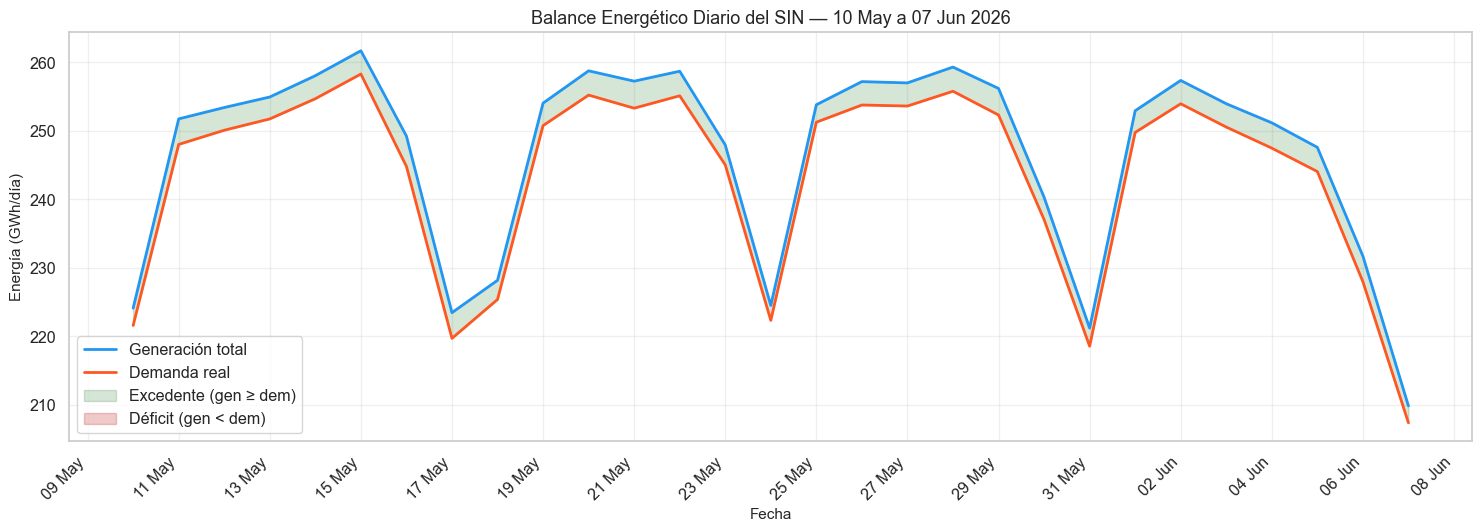


📈 Balance del período:
   Balance promedio diario:   +3.31 GWh
   Días con excedente:        29 / 29
   Días con déficit:          0 / 29
   Mayor excedente diario:    +4.43 GWh
   Mayor déficit diario:      +2.18 GWh


In [21]:
# Aplicación de la función de graficar balance diario
fig = graficar_balance_diario(tablas.get("resumen_diario", pd.DataFrame()))
if fig:
    plt.show()

    # Estadísticas del balance
    rd = tablas["resumen_diario"]
    if "Balance_GWh" in rd.columns:
        bal = rd["Balance_GWh"].dropna()
        print(f"\n📈 Balance del período:")
        print(f"   Balance promedio diario:   {bal.mean():+.2f} GWh")
        print(f"   Días con excedente:        {(bal > 0).sum()} / {len(bal)}")
        print(f"   Días con déficit:          {(bal < 0).sum()} / {len(bal)}")
        print(f"   Mayor excedente diario:    {bal.max():+.2f} GWh")
        print(f"   Mayor déficit diario:      {bal.min():+.2f} GWh")

### 3.2 Perfil horario del balance

Al momento de cruzar la generación horaria con la demanda horaria del período completo se identifica el perfil intradiario entre estas. Normalmente en el caso de las horas nocturnas (18h–22h) se muestra el gap más ajustado debido a que la generación solar cae a cero mientras la demanda residencial se incrementa.

In [22]:
def graficar_perfil_horario_balance(sistema_h: pd.DataFrame, guardar: bool = True,) -> plt.Figure | None:
    """Muestra el Perfil horario promedio: generación total vs demanda + anotación del gap mínimo."""
    requeridas = {"Hora", "Generacion_Total_kWh", "Demanda_kWh"}
    if sistema_h.empty or not requeridas.issubset(sistema_h.columns):
        print("⚠️  Faltan columnas para perfil horario de balance")
        return None

    perfil = (
        sistema_h.groupby("Hora", as_index=False)
        .agg(
            Gen_Prom_MW=("Generacion_Total_kWh", "mean"),
            Dem_Prom_MW=("Demanda_kWh", "mean"),
        )
    )
    perfil["Gen_Prom_MW"] /= 1e3   # kWh → MWh (integrado en 1h = MW promedio)
    perfil["Dem_Prom_MW"] /= 1e3
    perfil["Gap_MW"] = perfil["Gen_Prom_MW"] - perfil["Dem_Prom_MW"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(perfil["Hora"], perfil["Gen_Prom_MW"], marker="o",
             color=COLORES_METRICA["generacion"], linewidth=2, label="Generación promedio")
    ax1.plot(perfil["Hora"], perfil["Dem_Prom_MW"], marker="s",
             color=COLORES_METRICA["demanda"], linewidth=2, label="Demanda promedio")
    ax1.fill_between(perfil["Hora"], perfil["Gen_Prom_MW"], perfil["Dem_Prom_MW"],
                     alpha=0.15, color="#4CAF50")
    ax1.set_ylabel("Energía horaria promedio (MWh/h)")
    ax1.set_title("Perfil Horario Promedio — Generación vs Demanda del SIN")
    ax1.legend(loc="best")

    # Anotar la hora de gap mínimo (mayor riesgo)
    idx_min = perfil["Gap_MW"].idxmin()
    hora_min = int(perfil.loc[idx_min, "Hora"])
    gap_min  = perfil.loc[idx_min, "Gap_MW"]
    ax1.annotate(
        f"Gap mínimo\n{hora_min}h → {gap_min:+,.0f} MWh",
        xy=(hora_min, perfil.loc[idx_min, "Gen_Prom_MW"]),
        xytext=(hora_min + 1, perfil["Gen_Prom_MW"].max() * 0.95),
        arrowprops=dict(arrowstyle="->", color="#C62828"),
        fontsize=10, color="#C62828", fontweight="bold",
    )

    # Panel inferior: barras del gap
    colores_gap = np.where(perfil["Gap_MW"] >= 0, "#2E7D32", "#C62828")
    ax2.bar(perfil["Hora"], perfil["Gap_MW"], color=colores_gap, alpha=0.75)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("Hora del día")
    ax2.set_ylabel("Gap (MWh/h)")
    ax2.set_xticks(range(1, 25))
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_02_perfil_horario_balance_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig



💾 Figura guardada: fig_v2_02_perfil_horario_balance_20260510_20260607.png


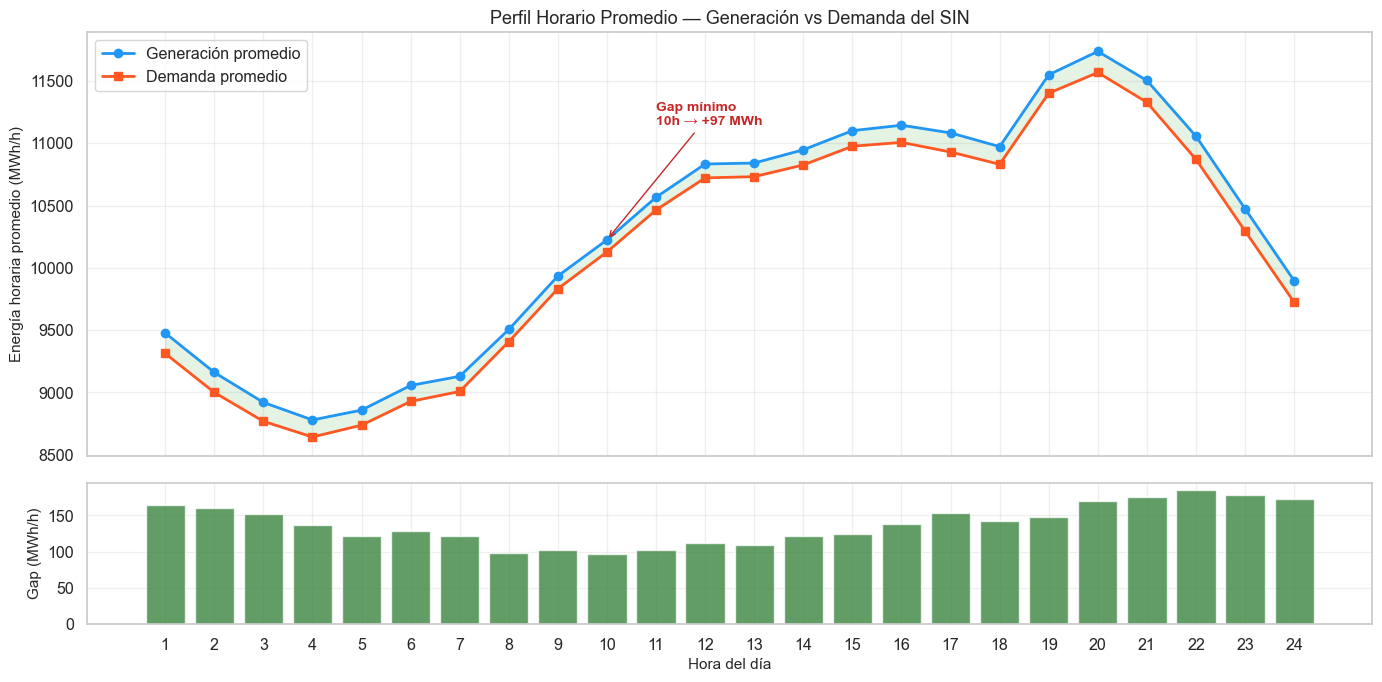

In [23]:
# Comprobación de perfil horario de balance
fig = graficar_perfil_horario_balance(tablas.get("sistema_h", pd.DataFrame()))
if fig:
    plt.show()

---
## 💰 Sección 4 — Precio de bolsa y señales de mercado

### 4.1 Serie temporal del precio de bolsa

Dentro del catálogo de métricas mostradas en la API de XM, se
puede identificar la de `PrecBolsNaci`, la cual parte del precio de oferta de la última
planta flexible que atiende la demanda comercial nacional e incorpora un delta
para remunerar costos no cubiertos de plantas térmicas en el despacho ideal. El
notebook resume la serie horaria con promedio, mínimo y máximo diario.

`PrecEsca` se usa como referencia de comparación. Su interpretación vigente debe
dependiendo del período estudiado.

In [24]:
def graficar_precio_serie(resumen_diario: pd.DataFrame, guardar: bool = True,) -> plt.Figure | None:
    """Serie temporal del precio con banda min-max y línea del precio de escasez."""
    requeridas = {"Fecha", "Precio_Prom_COP", "Precio_Min_COP", "Precio_Max_COP"}
    if resumen_diario.empty or not requeridas.issubset(resumen_diario.columns):
        print("⚠️  Faltan columnas para serie de precio")
        return None

    df = resumen_diario.dropna(subset=["Precio_Prom_COP"]).copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.fill_between(df["Fecha"], df["Precio_Min_COP"], df["Precio_Max_COP"],
                    alpha=0.2, color=COLORES_METRICA["precio"], label="Rango intra-día (min-max)")
    ax.plot(df["Fecha"], df["Precio_Prom_COP"],
            color="#F57C00", linewidth=2, marker="o", markersize=4,
            label="Precio promedio diario")

    # Línea de precio de escasez (si esta disponible)
    if "Precio_Escasez_COP_kWh" in df.columns and df["Precio_Escasez_COP_kWh"].notna().any():
        prom_escasez = df["Precio_Escasez_COP_kWh"].mean()
        ax.axhline(prom_escasez, color=COLORES_METRICA["escasez"],
                   linestyle="--", linewidth=1.5, alpha=0.8,
                   label=f"Precio de escasez (~{prom_escasez:,.0f} COP/kWh)")

    ax.set_title(f"Precio de Bolsa Nacional — {df['Fecha'].min():%d %b} a {df['Fecha'].max():%d %b %Y}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Precio (COP/kWh)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, len(df)//10)))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(loc="best")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_03_precio_bolsa_serie_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_03_precio_bolsa_serie_20260510_20260607.png


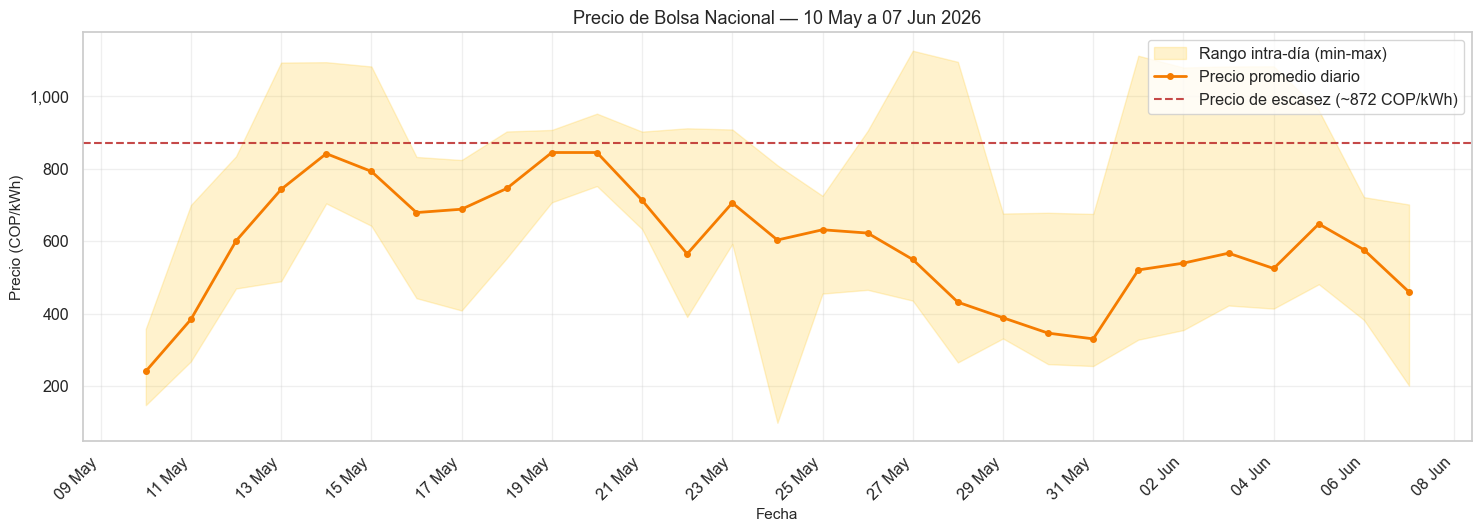


💰 Estadísticas de precio del período:
   Precio promedio del período:     590.8 COP/kWh
   Precio mínimo horario:            98.7 COP/kWh
   Precio máximo horario:         1,126.1 COP/kWh
   Volatilidad diaria promedio:     461.5 COP/kWh


In [25]:
# Grafica para la comprobación de la serie de precio de bolsa
fig = graficar_precio_serie(tablas.get("resumen_diario", pd.DataFrame()))
if fig:
    plt.show()

    rd = tablas["resumen_diario"]
    if "Precio_Prom_COP" in rd.columns:
        print(f"\n💰 Estadísticas de precio del período:")
        print(f"   Precio promedio del período:  {rd['Precio_Prom_COP'].mean():>8,.1f} COP/kWh")
        print(f"   Precio mínimo horario:        {rd['Precio_Min_COP'].min():>8,.1f} COP/kWh")
        print(f"   Precio máximo horario:        {rd['Precio_Max_COP'].max():>8,.1f} COP/kWh")
        print(f"   Volatilidad diaria promedio:  {(rd['Precio_Max_COP']-rd['Precio_Min_COP']).mean():>8,.1f} COP/kWh")

### 4.2 Asociación precio hidro–térmica

La disponibilidad hídrica y la composición de la generación pueden relacionarse
con el precio, pero el mecanismo también incluye aspectos de ofertas, restricciones, demanda, entre otras variables.
Los gráficos siguientes son exploratorios: cuantifican asociación lineal y no establecen causalidad.

In [26]:
def _tendencia_valida(ax, x: pd.Series, y: pd.Series, color: str) -> float | None:
    """Dibuja una tendencia lineal cuando existen datos y variación suficientes."""
    limpio = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(limpio) < 3 or limpio["x"].nunique() < 2 or limpio["y"].nunique() < 2:
        ax.text(0.03, 0.95, "Datos insuficientes para tendencia",
                transform=ax.transAxes, va="top")
        return None
    pendiente, intercepto = np.polyfit(limpio["x"], limpio["y"], 1)
    eje_x = np.linspace(limpio["x"].min(), limpio["x"].max(), 100)
    ax.plot(eje_x, pendiente * eje_x + intercepto,
            color=color, linewidth=2, linestyle="--")
    return limpio["x"].corr(limpio["y"])


def _configurar_scatter_correlacion(
    ax,
    df: pd.DataFrame,
    x: str,
    y: str,
    color: str,
    titulo: str,
    xlabel: str,
) -> float | None:
    """Aplica el mismo estilo y validaciones a todos los scatters de correlación."""
    limpio = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if limpio.empty:
        ax.text(0.5, 0.5, "Datos no disponibles",
                transform=ax.transAxes, ha="center", va="center")
        ax.set_title(titulo)
        return None
    ax.scatter(limpio[x], limpio[y], alpha=0.72, s=70, color=color,
               edgecolor="white", linewidth=0.8)
    correlacion = _tendencia_valida(ax, limpio[x], limpio[y], "#263238")
    sufijo = f"\nPearson r = {correlacion:+.2f}" if correlacion is not None else ""
    ax.set_title(titulo + sufijo, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Precio promedio diario (COP/kWh)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda valor, _: f"{valor:,.0f}"))
    ax.grid(alpha=0.22)
    return correlacion


def graficar_correlacion_precio(
    resumen_diario: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Mantiene la figura unificada para facilitar la comparación entre paneles."""
    requeridas = {"Precio_Prom_COP", "Nivel_Embalses_Pct"}
    if resumen_diario.empty or not requeridas.issubset(resumen_diario.columns):
        print("⚠️  Faltan columnas para correlación precio–embalses.")
        return None

    datos = resumen_diario.copy()
    tiene_termica = (
        "Participacion_Termica_pct" in datos
        and datos["Participacion_Termica_pct"].notna().any()
    )
    columnas = 2 if tiene_termica else 1
    fig, axes = plt.subplots(1, columnas, figsize=(15 if tiene_termica else 8, 5.5))
    axes = np.atleast_1d(axes)

    _configurar_scatter_correlacion(
        axes[0], datos, "Nivel_Embalses_Pct", "Precio_Prom_COP",
        COLORES_METRICA["embalses"], "Precio vs. nivel de embalses",
        "Nivel de embalses (%)",
    )
    if tiene_termica:
        _configurar_scatter_correlacion(
            axes[1], datos, "Participacion_Termica_pct", "Precio_Prom_COP",
            COLORES_TECNO["TERMICA"], "Precio vs. participación térmica",
            "Participación térmica (%)",
        )

    fig.suptitle(
        "Asociaciones exploratorias del precio de bolsa",
        fontsize=15, fontweight="bold", y=1.02,
    )
    fig.text(0.5, -0.01, "Correlación no implica causalidad.",
             ha="center", color="#546E7A")
    plt.tight_layout()
    if guardar:
        ruta = FIG_DIR / f"fig_v2_04_correlacion_precio_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_04_correlacion_precio_20260510_20260607.png


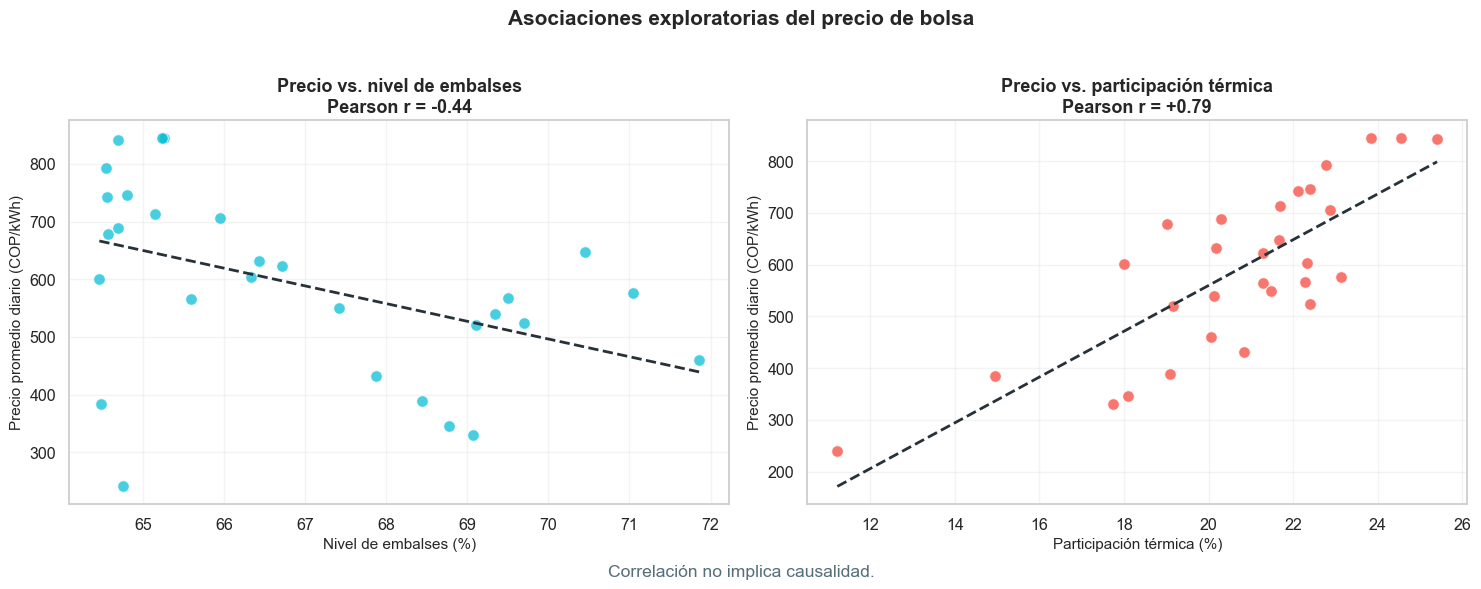

In [27]:
# Obtencion de la figura de correlación unificada entre precio y embalses/participación térmica
fig_correlacion_unificada = graficar_correlacion_precio(
    tablas.get("resumen_diario", pd.DataFrame()))

if fig_correlacion_unificada:
    plt.show()

#### 4.2.1 Figuras de correlación separadas

Además de la figura unificada, cada relación se exporta individualmente. Esta
opción mejora la legibilidad en presentaciones y permite usar escalas o textos
independientes sin reducir el tamaño de los puntos.

In [28]:
def graficar_correlacion_separada(
    resumen_diario: pd.DataFrame,
    x: str,
    color: str,
    titulo: str,
    xlabel: str,
    nombre_archivo: str,
    guardar: bool = True,
) -> plt.Figure | None:
    """Genera un scatter individual para presentaciones o lectura detallada."""
    if resumen_diario.empty or not {x, "Precio_Prom_COP"}.issubset(resumen_diario.columns):
        print(f"⚠️  No se puede generar {nombre_archivo}: faltan datos.")
        return None
    fig, ax = plt.subplots(figsize=(8.5, 6))
    _configurar_scatter_correlacion(
        ax, resumen_diario, x, "Precio_Prom_COP", color, titulo, xlabel
    )
    fig.text(0.5, 0.01, "Análisis exploratorio; correlación no implica causalidad.",
             ha="center", color="#546E7A", fontsize=9)
    plt.tight_layout(rect=(0, 0.03, 1, 1))
    if guardar:
        ruta = FIG_DIR / f"{nombre_archivo}_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_04_2_precio_termica_20260510_20260607.png


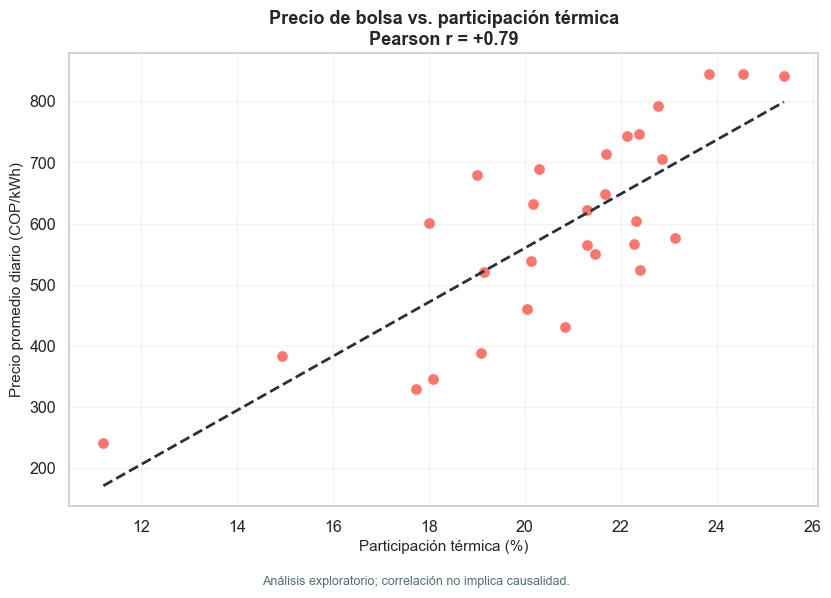

In [29]:
# Generación de scatter individual para correlación precio vs. participación térmica
fig_precio_termica = graficar_correlacion_separada(
    tablas.get("resumen_diario", pd.DataFrame()),
    x="Participacion_Termica_pct",
    color=COLORES_TECNO["TERMICA"],
    titulo="Precio de bolsa vs. participación térmica",
    xlabel="Participación térmica (%)",
    nombre_archivo="fig_v2_04_2_precio_termica",
)
if fig_precio_termica:
    plt.show()

💾 Figura guardada: fig_v2_04_1_precio_embalses_20260510_20260607.png


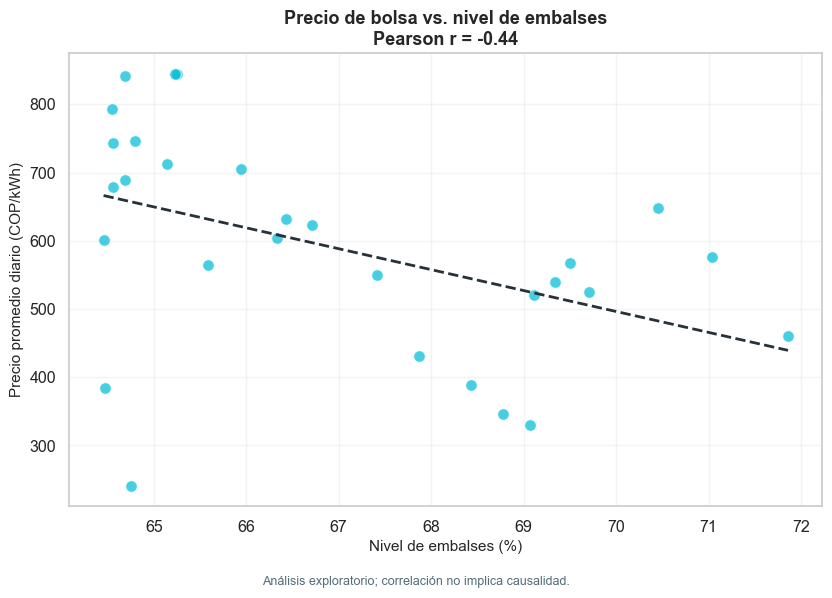

In [30]:
# Generación de scatter individual para correlación precio vs. nivel de embalses
fig_precio_embalses = graficar_correlacion_separada(
    tablas.get("resumen_diario", pd.DataFrame()),
    x="Nivel_Embalses_Pct",
    color=COLORES_METRICA["embalses"],
    titulo="Precio de bolsa vs. nivel de embalses",
    xlabel="Nivel de embalses (%)",
    nombre_archivo="fig_v2_04_1_precio_embalses",
)
if fig_precio_embalses:
    plt.show()

#### 4.2.2 Matriz de correlación — vista triangular

La vista triangular elimina la mitad duplicada de la matriz, utiliza nombres
cortos y mantiene una escala simétrica entre −1 y 1.

In [31]:
# Se determinaron las etiquetas legibles para la matriz de correlación, 
# que se utilizarán en la visualización de la misma.
ETIQUETAS_CORRELACION = {
    "Precio_Prom_COP": "Precio",
    "Nivel_Embalses_Pct": "Embalses",
    "Aportes_GWh": "Aportes",
    "Participacion_Termica_pct": "% térmica",
    "Gen_HIDRAULICA_GWh": "Gen. hidráulica",
    "Gen_TERMICA_GWh": "Gen. térmica",
    "Gen_SOLAR_GWh": "Gen. solar",
    "Demanda_GWh": "Demanda",
}


def preparar_matriz_correlacion(resumen_diario: pd.DataFrame) -> pd.DataFrame:
    """Selecciona variables con variación y asigna etiquetas legibles."""
    columnas = [
        col for col in ETIQUETAS_CORRELACION
        if col in resumen_diario.columns
        and resumen_diario[col].nunique(dropna=True) > 1
    ]
    if len(columnas) < 3:
        return pd.DataFrame()
    matriz = resumen_diario[columnas].corr(numeric_only=True)
    etiquetas = [ETIQUETAS_CORRELACION[col] for col in matriz.columns]
    matriz.index = etiquetas
    matriz.columns = etiquetas
    return matriz


def graficar_matriz_correlacion(
    resumen_diario: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Heatmap triangular: reduce duplicación visual y mejora la lectura."""
    matriz = preparar_matriz_correlacion(resumen_diario)
    if matriz.empty:
        print("⚠️  Se requieren al menos tres variables para la matriz.")
        return None
    mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
    cmap = sns.diverging_palette(240, 10, as_cmap=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        matriz, mask=mascara, annot=True, fmt=".2f",
        cmap=cmap, vmin=-1, vmax=1, center=0,
        square=True, linewidths=1.2, linecolor="white",
        cbar_kws={"label": "Coeficiente de Pearson", "shrink": 0.78},
        annot_kws={"fontsize": 10, "fontweight": "bold"},
        ax=ax,
    )
    ax.set_title(
        "Matriz de correlación del SIN — vista triangular",
        fontsize=15, fontweight="bold", pad=18,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    fig.text(0.5, 0.01, "Valores cercanos a ±1 indican mayor asociación lineal.",
             ha="center", color="#546E7A")
    plt.tight_layout(rect=(0, 0.035, 1, 1))
    if guardar:
        ruta = FIG_DIR / f"fig_v2_04b_matriz_correlacion_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=170, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_04b_matriz_correlacion_20260510_20260607.png


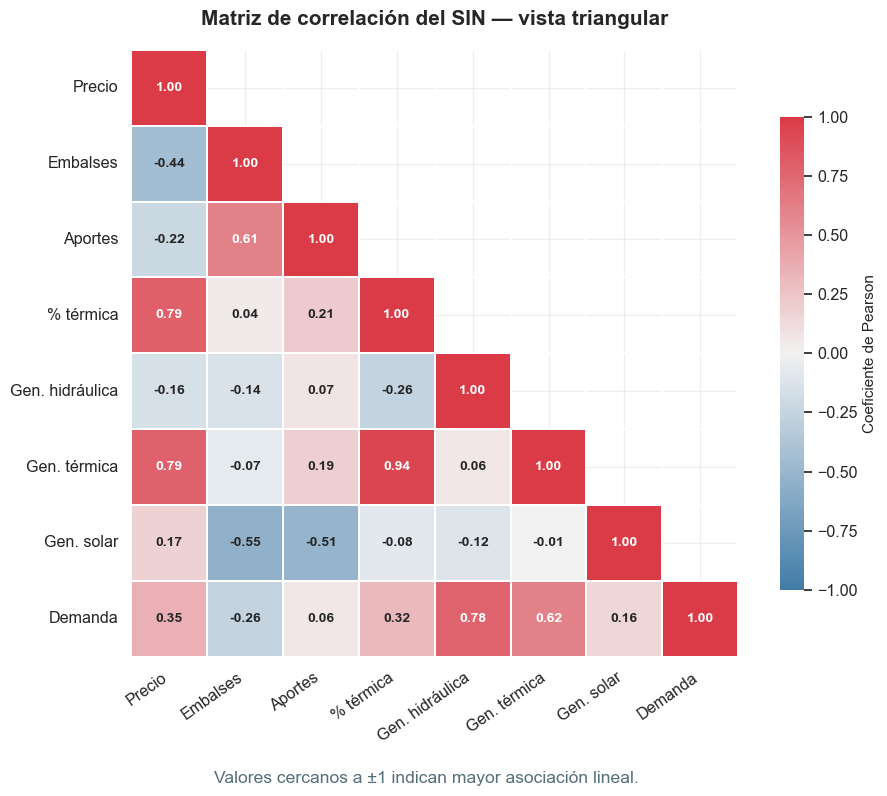

In [32]:
# Obtencion de la figura de matriz de correlación triangular
fig_matriz = graficar_matriz_correlacion(
    tablas.get("resumen_diario", pd.DataFrame())
)
if fig_matriz:
    plt.show()

#### 4.2.3 Alternativa visual — mapa de burbujas

El tamaño de cada burbuja representa la intensidad de la asociación y el color
indica su signo. Esta alternativa es útil cuando el heatmap se percibe muy
denso.

💾 Figura guardada: fig_v2_04c_correlacion_burbujas_20260510_20260607.png


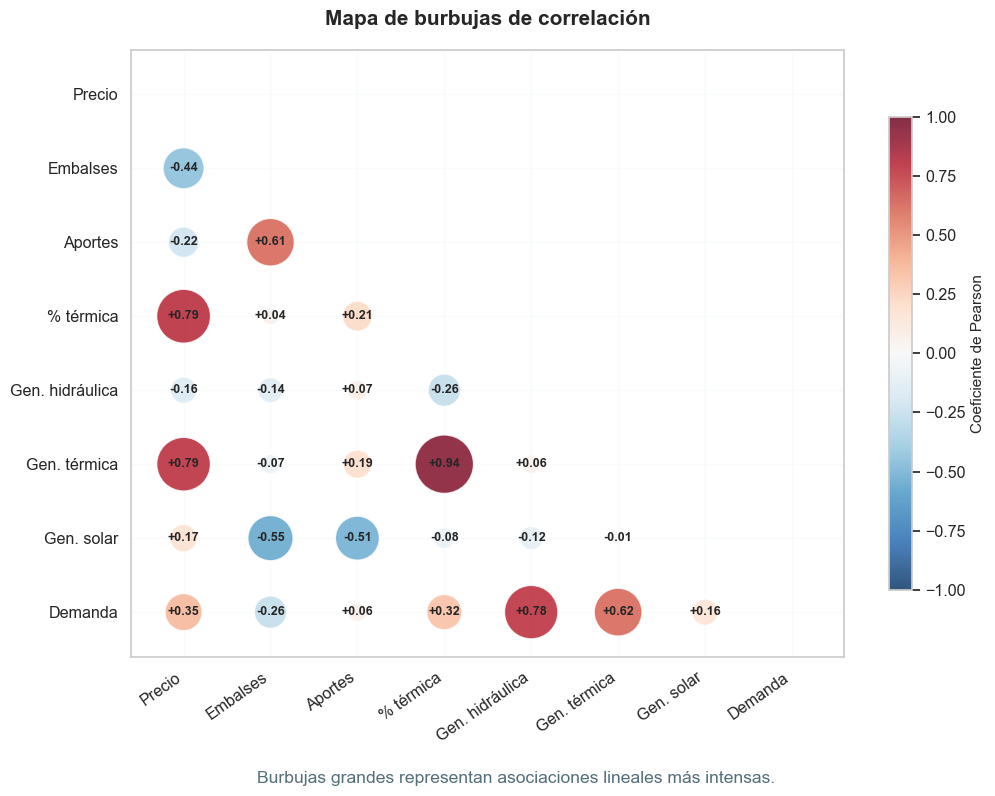

In [33]:
def graficar_correlacion_burbujas(
    resumen_diario: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Alternativa: tamaño = intensidad y color = signo de la correlación."""
    matriz = preparar_matriz_correlacion(resumen_diario)
    if matriz.empty:
        return None
    registros = []
    etiquetas = list(matriz.columns)
    for fila in range(len(etiquetas)):
        for columna in range(fila):
            registros.append({
                "x": columna,
                "y": fila,
                "correlacion": matriz.iloc[fila, columna],
            })
    largo = pd.DataFrame(registros)
    fig, ax = plt.subplots(figsize=(10.5, 8))
    puntos = ax.scatter(
        largo["x"], largo["y"],
        s=1800 * largo["correlacion"].abs() + 80,
        c=largo["correlacion"],
        cmap="RdBu_r", vmin=-1, vmax=1,
        alpha=0.82, edgecolor="white", linewidth=1,
    )
    for fila in largo.itertuples():
        ax.text(fila.x, fila.y, f"{fila.correlacion:+.2f}",
                ha="center", va="center", fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(etiquetas)), etiquetas, rotation=35, ha="right")
    ax.set_yticks(range(len(etiquetas)), etiquetas)
    ax.set_xlim(-0.6, len(etiquetas) - 0.4)
    ax.set_ylim(len(etiquetas) - 0.4, -0.6)
    ax.grid(color="#ECEFF1", linewidth=1)
    ax.set_axisbelow(True)
    ax.set_title(
        "Mapa de burbujas de correlación",
        fontsize=15, fontweight="bold", pad=18,
    )
    barra = fig.colorbar(puntos, ax=ax, shrink=0.78)
    barra.set_label("Coeficiente de Pearson")
    fig.text(0.5, 0.01, "Burbujas grandes representan asociaciones lineales más intensas.",
             ha="center", color="#546E7A")
    plt.tight_layout(rect=(0, 0.035, 1, 1))
    if guardar:
        ruta = FIG_DIR / f"fig_v2_04c_correlacion_burbujas_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=170, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


fig_burbujas = graficar_correlacion_burbujas(
    tablas.get("resumen_diario", pd.DataFrame())
)
if fig_burbujas:
    plt.show()

### 4.3 Perfil horario de precios: pico vs. valle *(preparación v2.5 SAEB)*

El diferencial entre ventanas horarias fijas es un **indicador exploratorio**. La
viabilidad de un SAEB requiere optimización diaria, eficiencia, degradación,
restricciones de potencia/energía, costos de conexión, liquidación y reglas de
participación. Por eso se reportan el spread bruto y un spread ajustado por
eficiencia, sin convertirlos todavía en una conclusión de inversión.

Ampliar mas la seccion

In [34]:
def graficar_perfil_horario_precios(
    fact_precio: pd.DataFrame,
    horas_pico: tuple[int, int] = HORAS_PICO,
    horas_valle: tuple[int, int] = HORAS_VALLE,
    guardar: bool = True,
) -> tuple[plt.Figure | None, dict]:
    """Boxplot horario y spreads exploratorios bruto/ajustado por eficiencia."""
    if fact_precio.empty or "Precio_COP_kWh" not in fact_precio.columns:
        print("⚠️  Faltan datos para perfil horario de precios")
        return None, {}

    df = fact_precio.dropna(subset=["Hora", "Precio_COP_kWh"]).copy()
    if df.empty:
        return None, {}

    def color_hora(hora: int) -> str:
        if horas_pico[0] <= hora <= horas_pico[1]:
            return "#C62828"
        if horas_valle[0] <= hora <= horas_valle[1]:
            return "#1976D2"
        return "#90A4AE"

    horas_orden = sorted(df["Hora"].astype(int).unique())
    palette = {hora: color_hora(hora) for hora in horas_orden}
    fig, ax = plt.subplots(figsize=(14, 5.5))
    sns.boxplot(data=df, x="Hora", y="Precio_COP_kWh", hue="Hora",
                palette=palette, order=horas_orden, legend=False,
                showfliers=False, ax=ax)
    ax.set_title("Distribución horaria del precio — valle (azul) y pico (rojo)")
    ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
    ax.set_ylabel("Precio de bolsa (COP/kWh)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    p_pico = df.loc[df["Hora"].between(*horas_pico), "Precio_COP_kWh"].mean()
    p_valle = df.loc[df["Hora"].between(*horas_valle), "Precio_COP_kWh"].mean()
    spread_bruto = p_pico - p_valle
    spread_neto = p_pico - p_valle / EFICIENCIA_RT_SAEB

    kpis = {
        "precio_pico_prom": p_pico,
        "precio_valle_prom": p_valle,
        "spread_bruto_COP_kWh": spread_bruto,
        "spread_ajustado_eficiencia_COP_kWh": spread_neto,
        "eficiencia_rt_referencia": EFICIENCIA_RT_SAEB,
        "horas_pico": horas_pico,
        "horas_valle": horas_valle,
    }

    ax.axhline(p_pico, color="#C62828", linestyle=":", linewidth=1.5, alpha=0.7)
    ax.axhline(p_valle, color="#1976D2", linestyle=":", linewidth=1.5, alpha=0.7)
    ax.text(
        0.02, 0.97,
        f"Pico: {p_pico:,.0f} COP/kWh\nValle: {p_valle:,.0f} COP/kWh\n"
        f"Spread bruto: {spread_bruto:,.0f} COP/kWh\n"
        f"Spread ajustado η={EFICIENCIA_RT_SAEB:.0%}: {spread_neto:,.0f} COP/kWh",
        transform=ax.transAxes, va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

    if guardar:
        ruta = FIG_DIR / f"fig_v2_05_perfil_horario_precios_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    plt.tight_layout()
    return fig, kpis

💾 Figura guardada: fig_v2_05_perfil_horario_precios_20260510_20260607.png


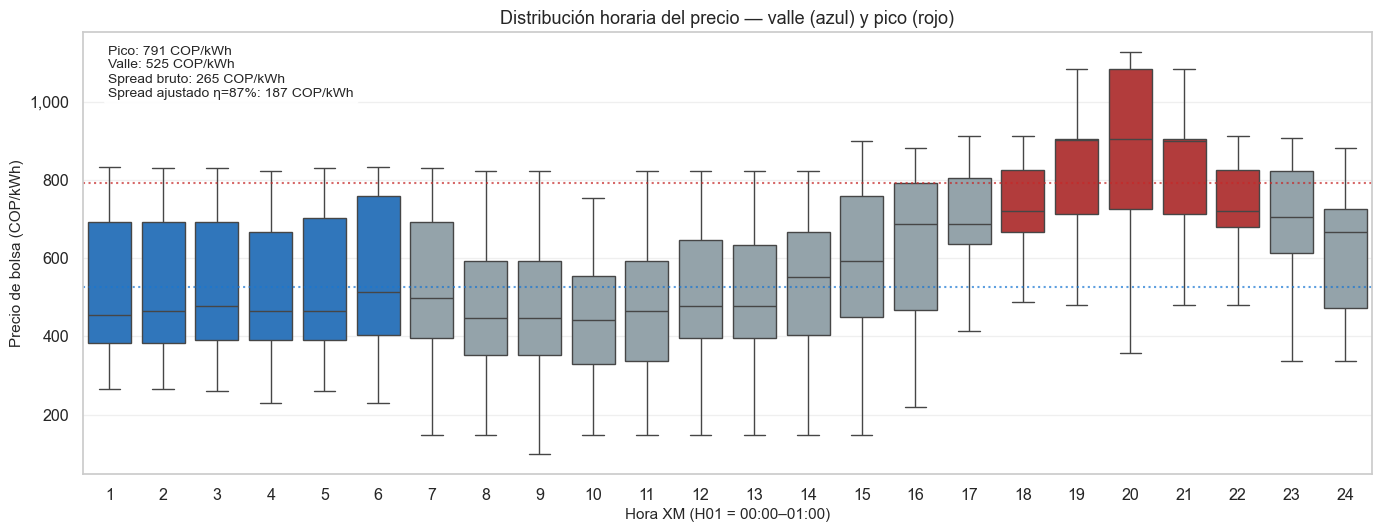


⚡ Inputs exploratorios para v2.5 (SAEB):
   precio_pico_prom                           = 790.6492413793104
   precio_valle_prom                          = 525.4830022988506
   spread_bruto_COP_kWh                       = 265.16623908045983
   spread_ajustado_eficiencia_COP_kWh         = 186.64579046109134
   eficiencia_rt_referencia                   = 0.87
   horas_pico                                 = (18, 22)
   horas_valle                                = (1, 6)


In [35]:
# Obtencion de la figura de perfil horario de precios y los KPIs asociados
fig, kpis_saeb = graficar_perfil_horario_precios(tablas.get("fact_precio", pd.DataFrame()))
if fig:
    plt.show()
    print("\n⚡ Inputs exploratorios para v2.5 (SAEB):")
    for clave, valor in kpis_saeb.items():
        print(f"   {clave:42s} = {valor}")

---
## 🌊 Sección 5 — Contexto hídrico y seguridad del sistema

### 5.1 Nivel de embalses con bandas exploratorias

`PorcVoluUtilDiar` expresa el volumen útil agregado como porcentaje. Las bandas
60%/40% usadas abajo son **umbrales visuales configurables para exploración**;
no son declaraciones oficiales de alerta, racionamiento ni activación del Cargo
por Confiabilidad. Cualquier uso operativo debe contrastarse con publicaciones realizadas por XM.

| Banda analítica | Nivel | Uso en este notebook |
|:--|:--|:--|
| Normal | > 60% | Referencia visual |
| Seguimiento | 40–60% | Revisar tendencia y aportes |
| Estrés | < 40% | Priorizar análisis de escenarios |

In [36]:
def graficar_embalses_zonas(
    fact_embalses: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Nivel de embalses con axhspan de zonas de alerta y anotación del mínimo."""
    if fact_embalses.empty or "Nivel_Embalses_Pct" not in fact_embalses.columns:
        print("⚠️  Faltan datos de embalses")
        return None

    df = fact_embalses.dropna(subset=["Nivel_Embalses_Pct"]).copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    fig, ax = plt.subplots(figsize=(15, 5.5))

    # Zonas de alerta (bandas horizontales)
    ax.axhspan(UMBRAL_EMBALSES_ALERTA, 100, facecolor="#4CAF50", alpha=0.12, label="Zona normal (>60%)")
    ax.axhspan(UMBRAL_EMBALSES_CRITICO, UMBRAL_EMBALSES_ALERTA,
               facecolor="#FFC107", alpha=0.15, label="Seguimiento (40–60%)")
    ax.axhspan(0, UMBRAL_EMBALSES_CRITICO, facecolor="#F44336", alpha=0.15, label="Estrés (<40%)")

    ax.plot(df["Fecha"], df["Nivel_Embalses_Pct"],
            color=COLORES_METRICA["embalses"], linewidth=2.2, marker="o", markersize=3)

    # Anotación del mínimo
    idx_min = df["Nivel_Embalses_Pct"].idxmin()
    fecha_min = df.loc[idx_min, "Fecha"]
    val_min   = df.loc[idx_min, "Nivel_Embalses_Pct"]
    ax.annotate(
        f"Mínimo: {val_min:.1f}%\n{fecha_min:%d %b}",
        xy=(fecha_min, val_min),
        xytext=(fecha_min, val_min - 8),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=10, ha="center",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

    ax.set_title(f"Nivel de Embalses del SIN — {df['Fecha'].min():%d %b} a {df['Fecha'].max():%d %b %Y}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Volumen útil (%)")
    ax.set_ylim(max(0, df["Nivel_Embalses_Pct"].min() - 15), 100)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, len(df)//10)))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(loc="lower left")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_06_embalses_zonas_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_06_embalses_zonas_20260510_20260607.png


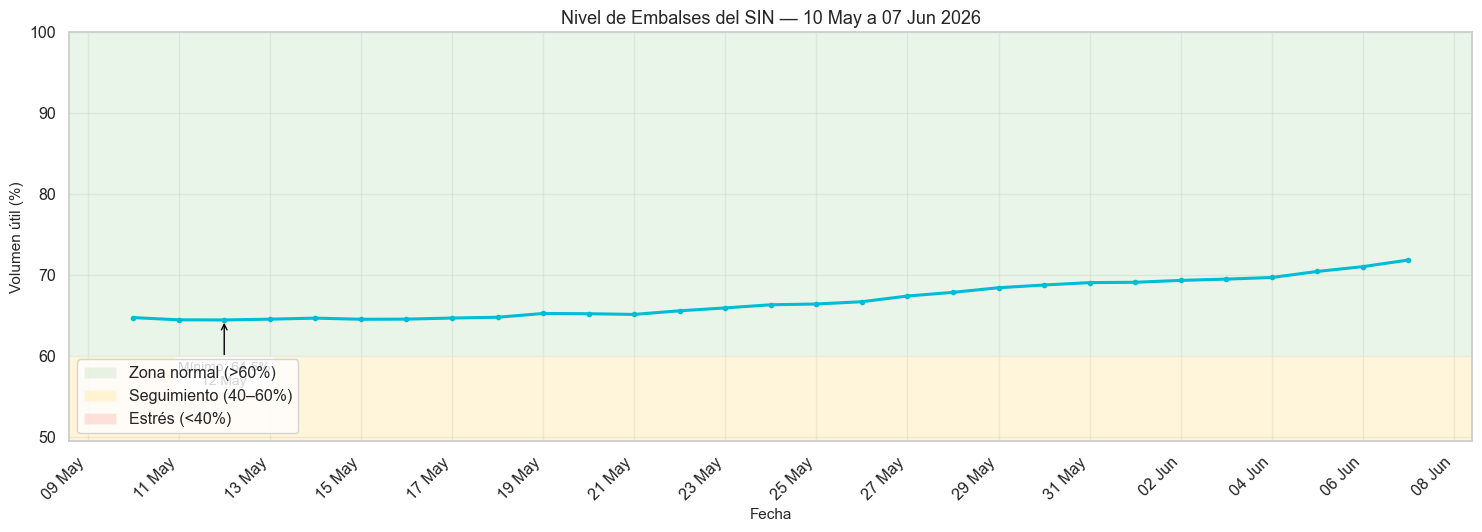

In [37]:
# Genero la grafica de embalses con zonas de alerta y crítico, si hay datos disponibles
fig = graficar_embalses_zonas(tablas.get("fact_embalses", pd.DataFrame()))
if fig:
    plt.show()

### 5.2 Aportes hídricos + correlación con embalses

Los aportes de energía hídrica (`AporEner`) miden la energía potencial que ingresa a los embalses desde los ríos. Es la variable macro más importante para proyectar el estado futuro del sistema.

- **Panel A:** Serie temporal de aportes diarios + media móvil de 7 días.
- **Panel B:** Aportes vs. cambio diario en el nivel de embalses (`delta_embalses`).

In [38]:
def graficar_aportes_y_delta(
    fact_aportes: pd.DataFrame,
    fact_embalses: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Panel A: aportes diarios + MM7. Panel B: aportes vs delta de embalses."""
    requeridas = {"Fecha", "Aportes_kWh"}
    if fact_aportes.empty or not requeridas.issubset(fact_aportes.columns):
        print("⚠️  Faltan datos de aportes")
        return None

    ap = fact_aportes.dropna(subset=["Fecha", "Aportes_kWh"]).copy()
    ap["Fecha"] = pd.to_datetime(ap["Fecha"])
    ap["Aportes_GWh"] = ap["Aportes_kWh"] / 1e6
    ap = ap.sort_values("Fecha").reset_index(drop=True)
    ap["MM7"] = ap["Aportes_GWh"].rolling(window=7, min_periods=1).mean()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].bar(ap["Fecha"], ap["Aportes_GWh"], color=COLORES_METRICA["aportes"],
                alpha=0.55, label="Aportes diarios")
    axes[0].plot(ap["Fecha"], ap["MM7"], color="#33691E", linewidth=2.2,
                 label="Media móvil 7 días")
    axes[0].set_title("Aportes hídricos diarios (GWh) + MM7")
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel("Aportes (GWh/día)")
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")
    axes[0].legend()

    ax = axes[1]
    if not fact_embalses.empty and {"Fecha", "Nivel_Embalses_Pct"}.issubset(fact_embalses.columns):
        emb = fact_embalses.dropna(subset=["Fecha", "Nivel_Embalses_Pct"]).copy()
        emb["Fecha"] = pd.to_datetime(emb["Fecha"])
        emb = emb.sort_values("Fecha").reset_index(drop=True)
        emb["Delta_Embalses"] = emb["Nivel_Embalses_Pct"].diff()
        merged = ap.merge(emb[["Fecha", "Delta_Embalses"]], on="Fecha", how="inner").dropna()
        if len(merged) >= 3:
            ax.scatter(merged["Aportes_GWh"], merged["Delta_Embalses"],
                       alpha=0.7, s=55, color=COLORES_METRICA["embalses"], edgecolor="black", linewidth=0.5)
            x, y = merged["Aportes_GWh"], merged["Delta_Embalses"]
            r = _tendencia_valida(ax, x, y, "#B71C1C")
            ax.axhline(0, color="black", linewidth=0.5, alpha=0.5)
            titulo_r = f" (r = {r:+.2f})" if r is not None else ""
            ax.set_title(f"Aportes vs Δ embalses diario{titulo_r}")
            ax.set_xlabel("Aportes (GWh/día)")
            ax.set_ylabel("Δ nivel embalses (p.p./día)")
        else:
            ax.text(0.5, 0.5, "Se requieren al menos 3 días comunes",
                    ha="center", va="center", transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, "No hay datos de embalses",
                ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()
    if guardar:
        ruta = FIG_DIR / f"fig_v2_07_aportes_delta_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig

💾 Figura guardada: fig_v2_07_aportes_delta_20260510_20260607.png


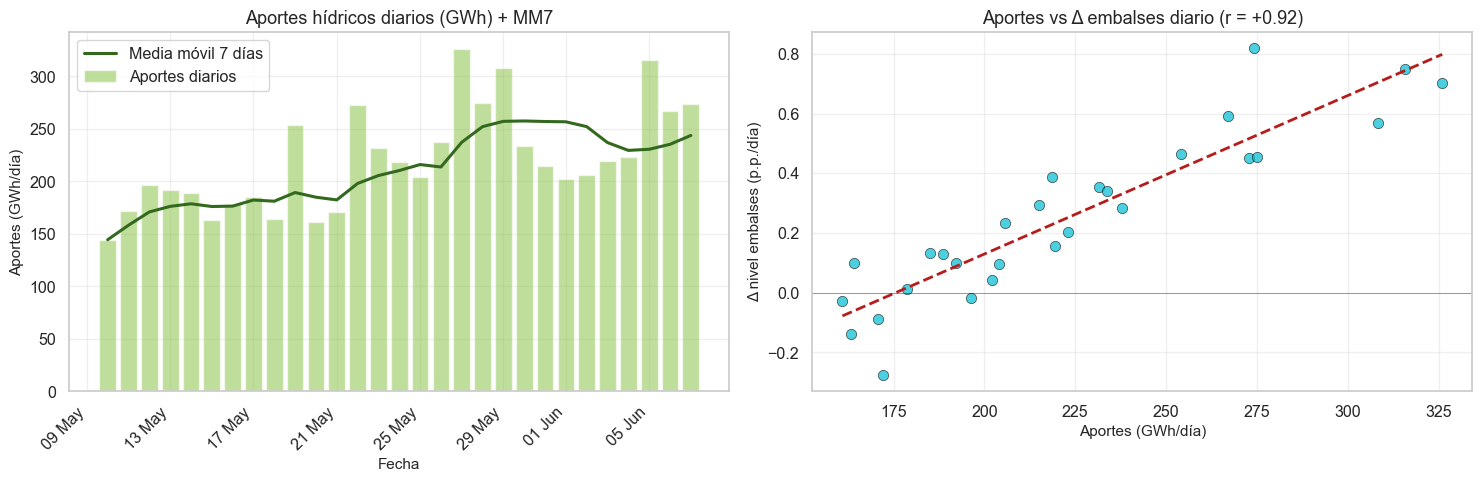

In [39]:
# Se genera la grafica de aportes y delta de embalses, si hay datos disponibles
fig = graficar_aportes_y_delta(
    tablas.get("fact_aportes", pd.DataFrame()),
    tablas.get("fact_embalses", pd.DataFrame()),
)
if fig:
    plt.show()

#### 5.2.1 Aportes y variación de embalses en figuras separadas

Se conservan los dos paneles unificados y se añaden versiones individuales para
facilitar la lectura, reutilización y exportación de cada análisis.

💾 Figura guardada: fig_v2_07a_aportes_serie_20260510_20260607.png


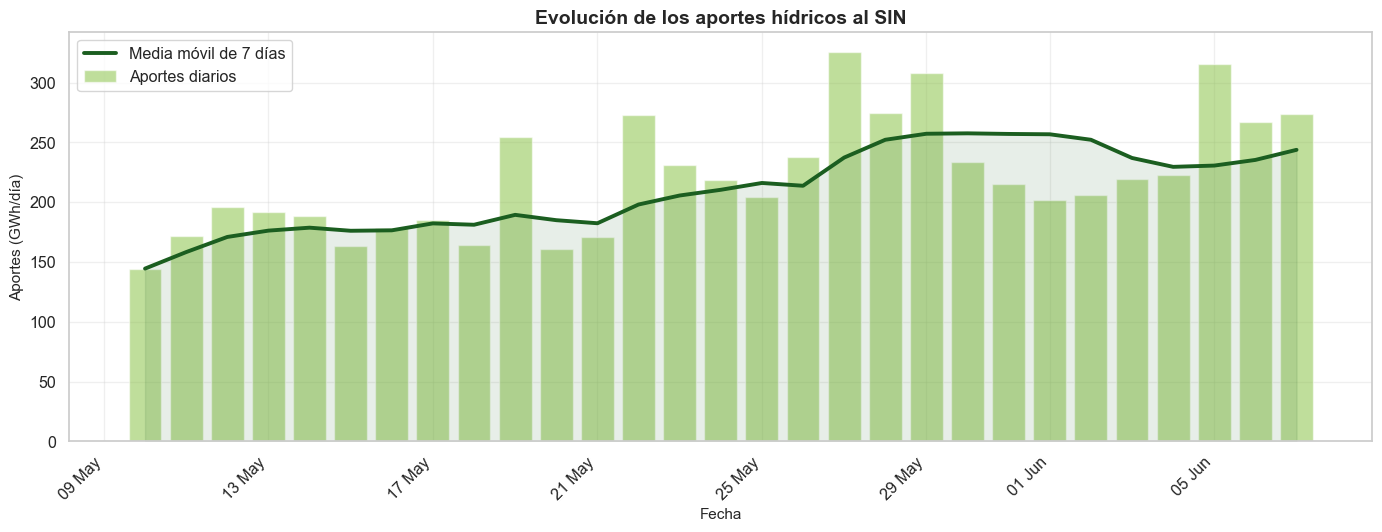

💾 Figura guardada: fig_v2_07b_aportes_vs_delta_20260510_20260607.png


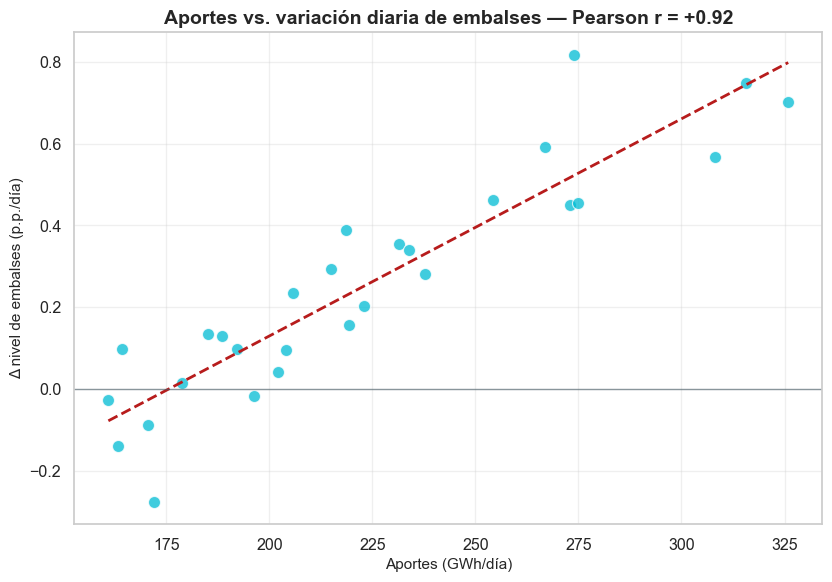

In [40]:
def _preparar_aportes(fact_aportes: pd.DataFrame) -> pd.DataFrame:
    if fact_aportes.empty or not {"Fecha", "Aportes_kWh"}.issubset(fact_aportes.columns):
        return pd.DataFrame()
    datos = fact_aportes.dropna(subset=["Fecha", "Aportes_kWh"]).copy()
    datos["Fecha"] = pd.to_datetime(datos["Fecha"])
    datos["Aportes_GWh"] = datos["Aportes_kWh"] / 1e6
    datos = datos.sort_values("Fecha").reset_index(drop=True)
    datos["MM7"] = datos["Aportes_GWh"].rolling(7, min_periods=1).mean()
    return datos


def graficar_aportes_serie_separada(
    fact_aportes: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Versión individual de aportes + media móvil."""
    datos = _preparar_aportes(fact_aportes)
    if datos.empty:
        print("⚠️  Faltan datos para la serie separada de aportes.")
        return None
    fig, ax = plt.subplots(figsize=(14, 5.5))
    ax.bar(datos["Fecha"], datos["Aportes_GWh"], color=COLORES_METRICA["aportes"],
           alpha=0.55, label="Aportes diarios")
    ax.plot(datos["Fecha"], datos["MM7"], color="#1B5E20", linewidth=2.8,
            label="Media móvil de 7 días")
    ax.fill_between(datos["Fecha"], datos["MM7"], alpha=0.10, color="#1B5E20")
    ax.set_title("Evolución de los aportes hídricos al SIN",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Aportes (GWh/día)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend()
    plt.tight_layout()
    if guardar:
        ruta = FIG_DIR / f"fig_v2_07a_aportes_serie_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


def graficar_aportes_delta_separada(
    fact_aportes: pd.DataFrame,
    fact_embalses: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Versión individual del scatter aportes vs. variación de embalses."""
    aportes = _preparar_aportes(fact_aportes)
    if aportes.empty or fact_embalses.empty:
        print("⚠️  Faltan aportes o embalses para el scatter separado.")
        return None
    embalses = fact_embalses.dropna(
        subset=["Fecha", "Nivel_Embalses_Pct"]
    ).copy()
    embalses["Fecha"] = pd.to_datetime(embalses["Fecha"])
    embalses = embalses.sort_values("Fecha")
    embalses["Delta_Embalses"] = embalses["Nivel_Embalses_Pct"].diff()
    datos = aportes.merge(
        embalses[["Fecha", "Delta_Embalses"]], on="Fecha", how="inner"
    ).dropna()
    if len(datos) < 3:
        print("⚠️  Se requieren al menos tres días comunes.")
        return None
    fig, ax = plt.subplots(figsize=(8.5, 6))
    ax.scatter(datos["Aportes_GWh"], datos["Delta_Embalses"],
               s=75, alpha=0.75, color=COLORES_METRICA["embalses"],
               edgecolor="white", linewidth=0.8)
    correlacion = _tendencia_valida(
        ax, datos["Aportes_GWh"], datos["Delta_Embalses"], "#B71C1C"
    )
    ax.axhline(0, color="#455A64", linewidth=1, alpha=0.6)
    titulo_r = f" — Pearson r = {correlacion:+.2f}" if correlacion is not None else ""
    ax.set_title("Aportes vs. variación diaria de embalses" + titulo_r,
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Aportes (GWh/día)")
    ax.set_ylabel("Δ nivel de embalses (p.p./día)")
    plt.tight_layout()
    if guardar:
        ruta = FIG_DIR / f"fig_v2_07b_aportes_vs_delta_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


fig_aportes_serie = graficar_aportes_serie_separada(
    tablas.get("fact_aportes", pd.DataFrame())
)
if fig_aportes_serie:
    plt.show()

fig_aportes_delta = graficar_aportes_delta_separada(
    tablas.get("fact_aportes", pd.DataFrame()),
    tablas.get("fact_embalses", pd.DataFrame()),
)
if fig_aportes_delta:
    plt.show()

---
## 🔥 Sección 6 — Perfil Horario Consolidado (Heatmaps)

### 6.1 Heatmap: generación por tecnología × hora del día

Mapa de calor que muestra la generación **promedio** por hora del día para cada tecnología. Revela los patrones intra-día característicos:
- **Solar** se concentra en 06h–18h con pico al mediodía.
- **Térmica** pica en horas punta (18h–22h).
- **Hidráulica** hace de balance seguidor de la demanda residual.

In [41]:
def graficar_heatmap_tecno_hora(
    gen_enriquecida: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Heatmap del total tecnológico horario promedio entre días."""
    requeridas = {"Tecnologia", "Fecha", "Hora", "Generacion_kWh"}
    if gen_enriquecida.empty or not requeridas.issubset(gen_enriquecida.columns):
        print("⚠️  Faltan datos enriquecidos para heatmap")
        return None

    # Primero total por tecnología-fecha-hora; después promedio entre días.
    # Esto evita promediar plantas individuales y etiquetarlo como total tecnológico.
    tecno_h_dia = (
        gen_enriquecida.groupby(["Tecnologia", "Fecha", "Hora"], as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
    )
    pivot = (
        tecno_h_dia.groupby(["Tecnologia", "Hora"])["Generacion_kWh"]
        .mean().div(1e6)
        .unstack(fill_value=0)
    )
    orden = tecno_h_dia.groupby("Tecnologia")["Generacion_kWh"].sum().sort_values(ascending=False).index
    pivot = pivot.reindex(orden)

    fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.7)))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
                cbar_kws={"label": "Generación tecnológica promedio (GWh/h)"},
                linewidths=0.3, ax=ax)
    ax.set_title("Perfil horario de generación total por tecnología (promedio diario)")
    ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
    ax.set_ylabel("Tecnología")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_08_heatmap_tecno_hora_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig

💾 Figura guardada: fig_v2_08_heatmap_tecno_hora_20260510_20260607.png


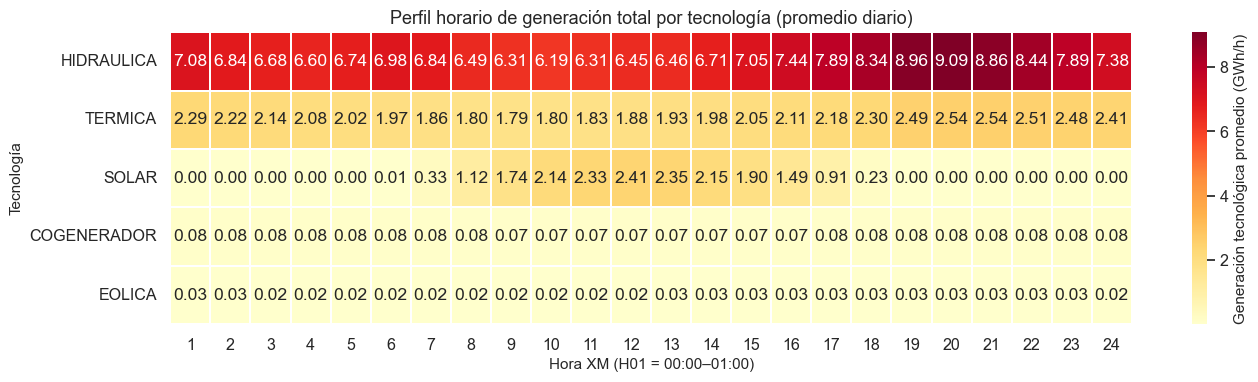

In [42]:
# Se genera la grafica de heatmap de generación por tecnología y hora, si hay datos disponibles
fig = graficar_heatmap_tecno_hora(tablas.get("gen_enriquecida", pd.DataFrame()))
if fig:
    plt.show()

#### 6.1.1 Alternativa al heatmap — perfiles por tecnología

Los pequeños múltiples muestran la curva horaria de cada tecnología y señalan
su hora de máxima generación promedio. Esta representación facilita comparar la
forma de los perfiles sin depender únicamente de la intensidad de color.

In [43]:
def preparar_perfil_tecnologia(gen_enriquecida: pd.DataFrame) -> pd.DataFrame:
    """Totaliza cada tecnología por fecha-hora y promedia entre días."""
    requeridas = {"Tecnologia", "Fecha", "Hora", "Generacion_kWh"}
    if gen_enriquecida.empty or not requeridas.issubset(gen_enriquecida.columns):
        return pd.DataFrame()
    diario = (
        gen_enriquecida.groupby(
            ["Tecnologia", "Fecha", "Hora"], as_index=False
        )["Generacion_kWh"].sum(min_count=1)
    )
    return (
        diario.groupby(["Tecnologia", "Hora"], as_index=False)["Generacion_kWh"]
        .mean()
        .assign(Generacion_GWh=lambda df: df["Generacion_kWh"] / 1e6)
    )


def graficar_perfiles_tecnologia_hora(
    gen_enriquecida: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Alternativa al heatmap: pequeños múltiples con áreas horarias."""
    perfil = preparar_perfil_tecnologia(gen_enriquecida)
    if perfil.empty:
        print("⚠️  Faltan datos para perfiles por tecnología.")
        return None
    orden = (
        perfil.groupby("Tecnologia")["Generacion_GWh"]
        .sum().sort_values(ascending=False).index.tolist()
    )
    columnas = 2
    filas = int(np.ceil(len(orden) / columnas))
    fig, axes = plt.subplots(
        filas, columnas, figsize=(15, 3.4 * filas),
        sharex=True, constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()
    for ax, tecnologia in zip(axes, orden):
        datos = perfil[perfil["Tecnologia"] == tecnologia]
        color = COLORES_TECNO.get(tecnologia, "#607D8B")
        ax.plot(datos["Hora"], datos["Generacion_GWh"],
                color=color, linewidth=2.4, marker="o", markersize=3)
        ax.fill_between(datos["Hora"], datos["Generacion_GWh"],
                        color=color, alpha=0.18)
        indice_pico = datos["Generacion_GWh"].idxmax()
        hora_pico = int(datos.loc[indice_pico, "Hora"])
        valor_pico = datos.loc[indice_pico, "Generacion_GWh"]
        ax.annotate(
            f"Pico H{hora_pico:02d}\n{valor_pico:.2f} GWh",
            xy=(hora_pico, valor_pico),
            xytext=(7, -8),
            textcoords="offset points",
            ha="left",
            va="top",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": color, "alpha": 0.82},
        )
        ax.set_title(tecnologia.title(), fontweight="bold", color=color)
        ax.set_ylabel("GWh/h")
        ax.set_xticks(range(1, 25, 2))
        ax.grid(alpha=0.22)
    for ax in axes[len(orden):]:
        ax.set_visible(False)
    for ax in axes[-columnas:]:
        if ax.get_visible():
            ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
    fig.suptitle(
        "Perfiles horarios promedio por tecnología — alternativa al heatmap",
        fontsize=16, fontweight="bold",
    )
    if guardar:
        ruta = FIG_DIR / f"fig_v2_08b_perfiles_tecnologia_hora_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_08b_perfiles_tecnologia_hora_20260510_20260607.png


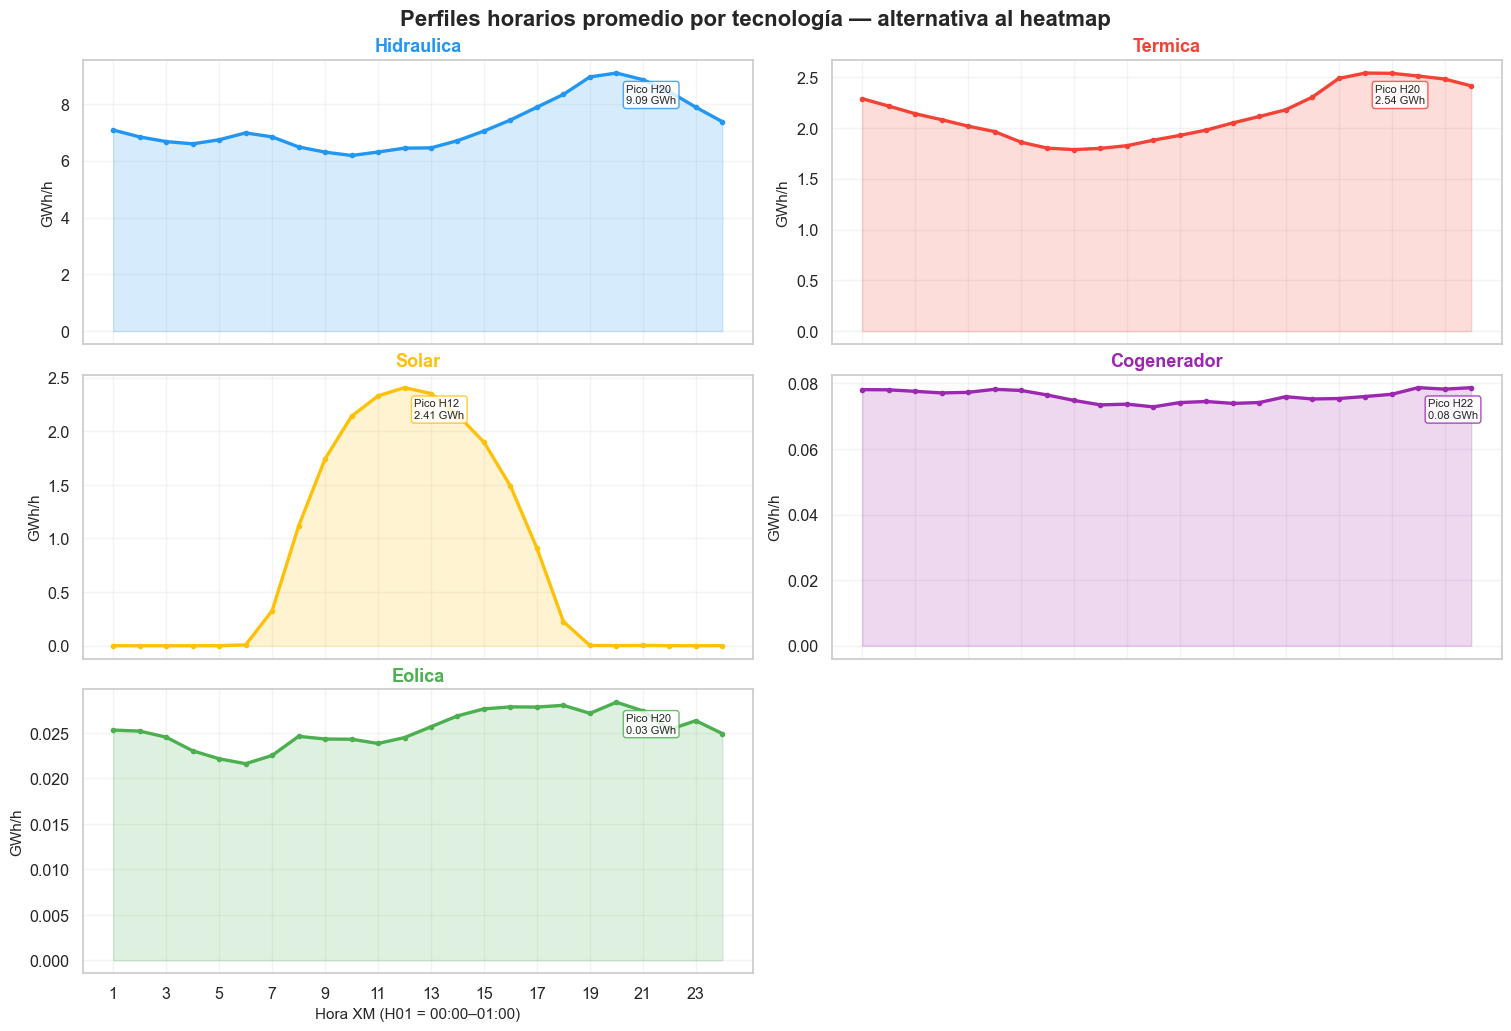

In [44]:
# Obtención de la figura de perfiles horarios promedio por tecnología
fig_perfiles_tecnologia = graficar_perfiles_tecnologia_hora(
    tablas.get("gen_enriquecida", pd.DataFrame()))

if fig_perfiles_tecnologia:
    plt.show()

#### 6.1.2 Explorador automático por área y subárea operativa

Esta sección incorpora la estructura operativa oficial publicada por SIMEM
para analizar la generación desde dos niveles jerárquicos:

- **Área operativa:** agrupación amplia utilizada en la operación del SIN.
- **Subárea operativa:** desagregación territorial-operativa dentro de un área.

SIMEM publica tres conjuntos de datos que deben combinarse:

| Dataset | Contenido utilizado | Papel dentro del modelo |
|:--|:--|:--|
| `0bfc9d` | Planta, área, subárea, tecnología y despacho | Tabla base |
| `841808` | Código y nombre del área operativa | Catálogo de áreas |
| `10F2C9` | Código y nombre de la subárea operativa | Catálogo de subáreas |

##### Flujo de la sección

```text
SIMEM 0bfc9d ─┬─► dimensión planta → área → subárea ─► control de cobertura
SIMEM 841808 ─┤                                      │
SIMEM 10F2C9 ─┘                                      ▼
Generación horaria ──────────────── left join ─► análisis y explorador operativo
```

El diseño aplica las siguientes reglas:

1. **Una sola implementación del ETL:** la descarga y construcción de la
   dimensión viven en `src/actualizar_areas_operativas_simem.py`.
2. **Ejecución reproducible:** por defecto se reutiliza la dimensión local.
3. **Conservación de datos:** el cruce parte de la generación y nunca elimina
   una fila por ausencia de catálogo.
4. **Ausencias visibles:** los códigos sin área o subárea quedan como
   `Sin asignar` y continúan en los totales nacionales.
5. **Cardinalidad validada:** `many_to_one` impide que códigos duplicados en la
   dimensión multipliquen artificialmente la energía.


##### 6.1.2.1 Configuración y carga de la dimensión SIMEM

El notebook actúa como **orquestador**: localiza el módulo versionado, le indica
si debe consultar la API y recibe una dimensión lista para utilizar.

- `ACTUALIZAR_AREAS_SIMEM=False`: reutiliza
  `data/reference/dim_plantas_areas_operativas.csv`.
- `ACTUALIZAR_AREAS_SIMEM=True`: consulta SIMEM y reemplaza la dimensión con la
  información más reciente disponible.
- `DIAS_RETROCESO_SIMEM`: número de días anteriores que se prueban cuando el día
  de referencia todavía no ha sido publicado.

Mantener la lógica en un archivo `.py` permite ejecutarla desde terminal,
probarla de forma independiente y evitar que el notebook acumule funciones de
infraestructura.


In [45]:
# Configuración reproducible: actualizar solo cuando se requiera una nueva foto.
ACTUALIZAR_AREAS_SIMEM = False
DIAS_RETROCESO_SIMEM = 7

import importlib.util
import sys


NIVELES_OPERATIVOS = {
    "Área operativa": "Area_Operativa",
    "Subárea operativa": "Subarea_Operativa",
}


def _localizar_script_operativo() -> Path:
    """Localiza el módulo SIMEM en el repositorio o en una propuesta local."""
    candidatos = [
        BASE_DIR / "src" / "actualizar_areas_operativas_simem.py",
        BASE_DIR / "scripts" / "actualizar_areas_operativas_simem.py",
    ]
    for candidato in candidatos:
        if candidato.exists():
            return candidato
    rutas = "\n- ".join(str(ruta) for ruta in candidatos)
    raise FileNotFoundError(
        "No se encontró actualizar_areas_operativas_simem.py. "
        f"Rutas revisadas:\n- {rutas}"
    )


def _cargar_modulo_operativo(ruta: Path):
    """Carga el ETL SIMEM sin modificar permanentemente ``sys.path``."""
    spec = importlib.util.spec_from_file_location("areas_operativas_v22", ruta)
    if spec is None or spec.loader is None:
        raise ImportError(f"No fue posible crear el cargador para {ruta}")
    modulo = importlib.util.module_from_spec(spec)
    # dataclass consulta sys.modules durante la carga del módulo.
    sys.modules[spec.name] = modulo
    spec.loader.exec_module(modulo)
    return modulo


ruta_script_operativo = _localizar_script_operativo()
operativo_mod = _cargar_modulo_operativo(ruta_script_operativo)

try:
    mapa_operativo, _ = operativo_mod.actualizar_dimension(
        base_dir=BASE_DIR,
        dias_retroceso=DIAS_RETROCESO_SIMEM,
        actualizar_api=ACTUALIZAR_AREAS_SIMEM,
    )
except (OSError, RuntimeError, ValueError, requests.RequestException) as exc:
    print(f"⚠️ No fue posible preparar la dimensión operativa: {exc}")
    mapa_operativo = pd.DataFrame()

print(f"Módulo utilizado: {ruta_script_operativo.relative_to(BASE_DIR)}")
if not mapa_operativo.empty:
    print(
        f"Dimensión operativa: {len(mapa_operativo):,} plantas | "
        f"Código SIC único: {mapa_operativo['Codigo_Planta'].is_unique}"
    )
    display(mapa_operativo.head())


Se reutiliza la dimension existente: G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\reference\dim_plantas_areas_operativas.csv
Módulo utilizado: src\actualizar_areas_operativas_simem.py
Dimensión operativa: 2,260 plantas | Código SIC único: True


,Codigo_Planta,Nombre_Planta_SIMEM,CodigoAreaOperativa,Area_Operativa,CodigoSubAreaOperativa,Subarea_Operativa,TipoGeneracion,TipoDespachoRecurso,CodigoSICAgente,Fecha,FechaPublicacion,Fuente
0,5J84,AGPE ACEIS FIC48 ZC,Are0002,Area Antioquia,Are0015,SubArea Antioquia,Solar,No Despachado Centralmente,NEUC,2026-08-03,2026-08-03,SIMEM 0bfc9d + 841808 + 10F2C9
1,4YJW,AGPE AGPE CENTRO EMPRESARIAL DANN FINANCIERA,Are0002,Area Antioquia,Are0015,SubArea Antioquia,Solar,No Despachado Centralmente,GNCC,2026-08-03,2026-08-03,SIMEM 0bfc9d + 841808 + 10F2C9
2,5EEQ,AGPE AGROFRUT,Are0002,Area Antioquia,Are0015,SubArea Antioquia,Solar,No Despachado Centralmente,EPMC,2026-08-03,2026-08-03,SIMEM 0bfc9d + 841808 + 10F2C9
3,5E6N,AGPE ALIMENTOS MUNOZ,Are0002,Area Antioquia,Are0015,SubArea Antioquia,Solar,No Despachado Centralmente,GNCC,2026-08-03,2026-08-03,SIMEM 0bfc9d + 841808 + 10F2C9
4,3C3B,AGPE ANDRES GOMEZ,Are0002,Area Antioquia,Are0015,SubArea Antioquia,Solar,No Despachado Centralmente,NEUC,2026-08-03,2026-08-03,SIMEM 0bfc9d + 841808 + 10F2C9


##### 6.1.2.2 Enriquecimiento de la generación

La dimensión contiene una fila por planta y la generación contiene múltiples
filas por Código SIC, fecha y hora. El cruce esperado es, por tanto,
`many_to_one`.

Se utiliza un `left join` desde la generación. Después del cruce se rellenan
únicamente las etiquetas operativas ausentes; la energía y los demás atributos
originales no se imputan ni se eliminan.


In [46]:
COLUMNAS_OPERATIVAS = [
    "Codigo_Planta",
    "CodigoAreaOperativa",
    "Area_Operativa",
    "CodigoSubAreaOperativa",
    "Subarea_Operativa",
]


def enriquecer_generacion_operativa(
    generacion: pd.DataFrame,
    dimension: pd.DataFrame,
) -> pd.DataFrame:
    """Añade área y subárea sin eliminar ni multiplicar la generación."""
    if generacion.empty or dimension.empty:
        return pd.DataFrame()
    if "Codigo_Planta" not in generacion.columns:
        raise ValueError("La generación no contiene Codigo_Planta.")
    if "Codigo_Planta" not in dimension.columns:
        raise ValueError("La dimensión SIMEM no contiene Codigo_Planta.")
    if not dimension["Codigo_Planta"].is_unique:
        raise ValueError("La dimensión SIMEM contiene códigos SIC duplicados.")

    faltantes = set(COLUMNAS_OPERATIVAS).difference(dimension.columns)
    if faltantes:
        raise ValueError(
            "La dimensión operativa no contiene las columnas: "
            f"{sorted(faltantes)}"
        )

    resultado = generacion.merge(
        dimension[COLUMNAS_OPERATIVAS],
        on="Codigo_Planta",
        how="left",
        validate="many_to_one",
    )
    for columna in NIVELES_OPERATIVOS.values():
        resultado[columna] = resultado[columna].fillna("Sin asignar")
    return resultado


generacion_operativa = enriquecer_generacion_operativa(
    generacion=tablas.get("gen_enriquecida", pd.DataFrame()),
    dimension=mapa_operativo,
)

if not generacion_operativa.empty:
    print(
        f"Generación operativa: {len(generacion_operativa):,} filas | "
        f"Plantas: {generacion_operativa['Codigo_Planta'].nunique():,}"
    )


Generación operativa: 318,624 filas | Plantas: 506


##### 6.1.2.3 Control de cobertura operativa

La calidad del cruce se evalúa desde dos perspectivas:

- **plantas asignadas:** proporción de códigos SIC con área operativa;
- **energía asignada:** proporción de la generación asociada a esas plantas.

Es normal que ambas cifras sean distintas: muchos recursos pequeños sin
correspondencia pueden representar poca energía. El control se exporta para que
la cobertura pueda compararse entre períodos y actualizaciones del catálogo.


In [47]:
def resumir_cobertura_operativa(
    generacion: pd.DataFrame,
) -> pd.DataFrame:
    """Resume la asignación operativa por número de plantas y energía."""
    if generacion.empty:
        return pd.DataFrame()

    asignada = generacion["Area_Operativa"].ne("Sin asignar")
    plantas_total = generacion["Codigo_Planta"].nunique()
    plantas_mapeadas = generacion.loc[asignada, "Codigo_Planta"].nunique()
    energia = pd.to_numeric(generacion["Generacion_kWh"], errors="coerce")
    energia_total = energia.sum()
    energia_mapeada = energia.loc[asignada].sum()

    return pd.DataFrame(
        {
            "Indicador": ["Plantas", "Generación"],
            "Total": [plantas_total, energia_total],
            "Mapeado": [plantas_mapeadas, energia_mapeada],
            "Cobertura_pct": [
                100 * plantas_mapeadas / max(1, plantas_total),
                100 * energia_mapeada / energia_total if energia_total else 0,
            ],
        }
    )


cobertura_operativa = resumir_cobertura_operativa(generacion_operativa)
if not cobertura_operativa.empty:
    display(
        cobertura_operativa.style.format(
            {
                "Total": "{:,.2f}",
                "Mapeado": "{:,.2f}",
                "Cobertura_pct": "{:.2f}%",
            }
        )
    )
    cobertura_operativa.to_csv(
        PROCESSED_DIR
        / f"qc_cobertura_areas_operativas_{ETIQUETA_PERIODO}.csv",
        index=False,
    )


,Indicador,Total,Mapeado,Cobertura_pct
0,Plantas,506.00,404.00,79.84%
1,Generación,"7,155,673,043.85","6,981,941,309.36",97.57%


##### 6.1.2.4 Funciones de consulta y resumen por área

Las funciones de esta etapa trabajan sobre datos ya preparados. No descargan
información ni cambian la dimensión, por lo que se pueden revisar y probar de
manera independiente.

El filtro valida explícitamente el nivel solicitado. El resumen conserva
`Sin asignar` con un color neutro para hacer visible cualquier brecha del
catálogo.


In [48]:
def _slug_operativo(texto: str) -> str:
    """Convierte una etiqueta en un fragmento seguro para nombres de archivo."""
    import re
    import unicodedata

    normalizado = unicodedata.normalize("NFKD", texto)
    ascii_texto = normalizado.encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-z0-9]+", "_", ascii_texto.lower()).strip("_")


def filtrar_generacion_operativa(
    generacion: pd.DataFrame,
    nivel: str,
    ambito: str,
) -> pd.DataFrame:
    """Filtra una copia por área o subárea; Nacional devuelve todas las filas."""
    if ambito == "Nacional":
        return generacion.copy()
    if nivel not in NIVELES_OPERATIVOS:
        raise ValueError(
            f"Nivel operativo no válido: {nivel}. "
            f"Opciones: {list(NIVELES_OPERATIVOS)}"
        )
    columna = NIVELES_OPERATIVOS[nivel]
    return generacion.loc[generacion[columna].eq(ambito)].copy()


def graficar_resumen_areas(
    generacion: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Compara la generación acumulada del período entre áreas operativas."""
    if generacion.empty:
        print("⚠️ No hay datos para construir el resumen operativo.")
        return None

    resumen = (
        generacion.groupby("Area_Operativa", as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
        .assign(Generacion_GWh=lambda df: df["Generacion_kWh"] / 1e6)
        .sort_values("Generacion_GWh")
    )
    colores = [
        "#90A4AE" if area == "Sin asignar" else "#1976D2"
        for area in resumen["Area_Operativa"]
    ]

    fig, ax = plt.subplots(figsize=(11, 6))
    barras = ax.barh(
        resumen["Area_Operativa"],
        resumen["Generacion_GWh"],
        color=colores,
        alpha=0.9,
    )
    ax.bar_label(barras, fmt="%.1f GWh", padding=4, fontsize=9)
    ax.set_title(
        "Generación acumulada por área operativa",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Generación del período (GWh)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.22)
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / (
            f"fig_v2_08c_generacion_area_operativa_{ETIQUETA_PERIODO}.png"
        )
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


##### 6.1.2.5 Visualizaciones horarias reutilizables

El heatmap y los perfiles separados utilizan el mismo agregado promedio por
tecnología y hora definido en 6.1.1:

- el **heatmap** favorece la comparación rápida entre tecnologías;
- los **paneles independientes** permiten observar fuentes pequeñas sin que la
  escala de la hidráulica o la térmica las oculte.

Las funciones reciben el subconjunto ya filtrado, de modo que sirven tanto para
la vista nacional como para cualquier área o subárea.


In [49]:
def graficar_heatmap_operativo(
    datos: pd.DataFrame,
    nivel: str,
    ambito: str,
    guardar: bool = True,
) -> plt.Figure | None:
    """Muestra el perfil tecnología × hora de un ámbito operativo."""
    perfil = preparar_perfil_tecnologia(datos)
    if perfil.empty:
        print(f"⚠️ No hay datos de generación para {ambito}.")
        return None

    pivot = perfil.pivot(
        index="Tecnologia",
        columns="Hora",
        values="Generacion_GWh",
    )
    orden = (
        perfil.groupby("Tecnologia")["Generacion_GWh"]
        .sum()
        .sort_values(ascending=False)
        .index
    )
    pivot = pivot.reindex(orden)

    fig, ax = plt.subplots(figsize=(15, max(4, 0.75 * len(pivot))))
    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        annot=True,
        fmt=".2f",
        linewidths=0.4,
        cbar_kws={"label": "Generación promedio (GWh/h)"},
        ax=ax,
    )
    ax.set_title(
        f"Generación por tecnología y hora — {ambito}",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Hora XM")
    ax.set_ylabel("Tecnología")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / (
            f"fig_v2_08d_{_slug_operativo(nivel)}_"
            f"{_slug_operativo(ambito)}_heatmap_{ETIQUETA_PERIODO}.png"
        )
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


def graficar_perfiles_operativos(
    datos: pd.DataFrame,
    nivel: str,
    ambito: str,
    guardar: bool = True,
) -> plt.Figure | None:
    """Dibuja una escala independiente para cada tecnología del ámbito."""
    perfil = preparar_perfil_tecnologia(datos)
    if perfil.empty:
        print(f"⚠️ No hay datos de generación para {ambito}.")
        return None

    orden = (
        perfil.groupby("Tecnologia")["Generacion_GWh"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )
    columnas = 2
    filas = int(np.ceil(len(orden) / columnas))
    fig, axes = plt.subplots(
        filas,
        columnas,
        figsize=(15, 3.3 * filas),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, tecnologia in zip(axes, orden):
        grupo = perfil.loc[perfil["Tecnologia"].eq(tecnologia)]
        color = COLORES_TECNO.get(tecnologia, "#607D8B")
        ax.plot(
            grupo["Hora"],
            grupo["Generacion_GWh"],
            marker="o",
            linewidth=2,
            color=color,
        )
        ax.fill_between(
            grupo["Hora"],
            grupo["Generacion_GWh"],
            color=color,
            alpha=0.16,
        )
        ax.set_title(tecnologia.title(), fontweight="bold", color=color)
        ax.set_ylabel("GWh/h")
        ax.set_xticks(range(1, 25, 2))
        ax.grid(alpha=0.22)

    for ax in axes[len(orden):]:
        ax.set_visible(False)
    for ax in axes[-columnas:]:
        if ax.get_visible():
            ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")

    fig.suptitle(
        f"Perfiles horarios de generación — {ambito}",
        fontsize=15,
        fontweight="bold",
    )
    if guardar:
        ruta = FIG_DIR / (
            f"fig_v2_08e_{_slug_operativo(nivel)}_"
            f"{_slug_operativo(ambito)}_perfiles_{ETIQUETA_PERIODO}.png"
        )
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


##### 6.1.2.6 Vista nacional e interfaz interactiva

La figura nacional se genera siempre y funciona como resultado estático de
referencia. La interfaz es opcional y se limita a coordinar los selectores; el
filtrado y las gráficas permanecen en funciones independientes.

Uso del explorador:

1. elegir área o subárea;
2. seleccionar el ámbito específico;
3. escoger `Heatmap`, `Perfiles` o `Ambas`;
4. presionar **Generar figura**.

Esta separación entre **datos**, **visualización** e **interfaz** facilita la
revisión y permite trasladar las mismas funciones a Streamlit en una versión
posterior.


💾 Figura guardada: fig_v2_08c_generacion_area_operativa_20260510_20260607.png


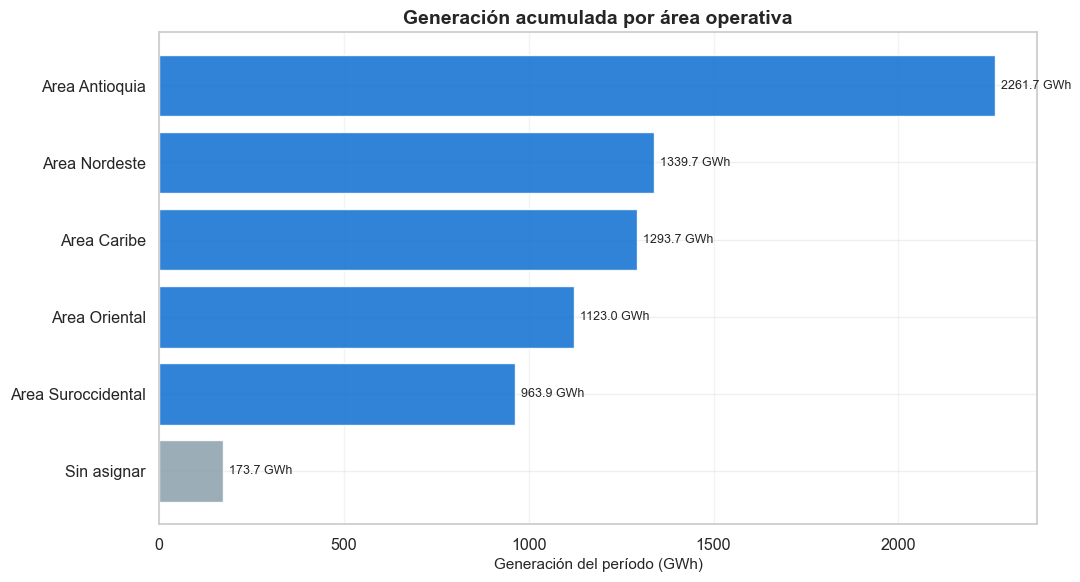

In [50]:
# Resultado base visible incluso cuando ipywidgets no está instalado.
fig_resumen_areas = graficar_resumen_areas(generacion_operativa)
if fig_resumen_areas is not None:
    plt.show()


In [51]:
def crear_explorador_operativo(generacion: pd.DataFrame):
    """Crea el selector operativo; devuelve ``None`` si no puede activarse."""
    if generacion.empty:
        print("⚠️ No hay generación operativa para activar el explorador.")
        return None

    try:
        import ipywidgets as widgets
        from IPython.display import clear_output
    except ImportError:
        print("ℹ️ Instala ipywidgets para utilizar el selector interactivo.")
        return None

    selector_nivel = widgets.Dropdown(
        options=list(NIVELES_OPERATIVOS),
        value="Área operativa",
        description="Nivel:",
    )
    selector_ambito = widgets.Dropdown(description="Ámbito:")
    selector_vista = widgets.ToggleButtons(
        options=["Heatmap", "Perfiles", "Ambas"],
        value="Heatmap",
        description="Vista:",
    )
    boton_graficar = widgets.Button(
        description="Generar figura",
        button_style="primary",
        icon="bar-chart",
    )
    salida = widgets.Output()

    def actualizar_ambitos(_=None) -> None:
        """Sincroniza los ámbitos disponibles con el nivel seleccionado."""
        columna = NIVELES_OPERATIVOS[selector_nivel.value]
        valores = sorted(generacion[columna].dropna().unique().tolist())
        selector_ambito.options = ["Nacional", *valores]
        selector_ambito.value = "Nacional"

    def actualizar_figura(_=None) -> None:
        """Filtra una vez y reutiliza el resultado en las vistas solicitadas."""
        with salida:
            clear_output(wait=True)
            nivel = selector_nivel.value
            ambito = selector_ambito.value
            datos_filtrados = filtrar_generacion_operativa(
                generacion,
                nivel,
                ambito,
            )
            energia_gwh = pd.to_numeric(
                datos_filtrados["Generacion_kWh"],
                errors="coerce",
            ).sum() / 1e6
            print(
                f"{nivel}: {ambito} | "
                f"Plantas: {datos_filtrados['Codigo_Planta'].nunique():,} | "
                f"Generación: {energia_gwh:,.2f} GWh"
            )

            if selector_vista.value in ("Heatmap", "Ambas"):
                figura = graficar_heatmap_operativo(
                    datos_filtrados,
                    nivel,
                    ambito,
                )
                if figura is not None:
                    plt.show()
            if selector_vista.value in ("Perfiles", "Ambas"):
                figura = graficar_perfiles_operativos(
                    datos_filtrados,
                    nivel,
                    ambito,
                )
                if figura is not None:
                    plt.show()

    selector_nivel.observe(actualizar_ambitos, names="value")
    boton_graficar.on_click(actualizar_figura)
    actualizar_ambitos()

    return widgets.VBox(
        [
            widgets.HTML("<b>Explorador operativo de generación — SIMEM</b>"),
            widgets.HBox(
                [
                    selector_nivel,
                    selector_ambito,
                    selector_vista,
                    boton_graficar,
                ]
            ),
            salida,
        ]
    )


explorador_operativo = crear_explorador_operativo(generacion_operativa)
if explorador_operativo is not None:
    display(explorador_operativo)


#### 6.1.3 Comparación de cobertura SIMEM–UPME y explorador geográfico

El objetivo de esta sección es **completar la dimensión de plantas**, no
reemplazar una fuente por otra. Cada catálogo responde una pregunta diferente:

| Fuente | Pregunta que ayuda a responder | Campos principales |
|:--|:--|:--|
| **SIMEM** | ¿Cómo se organiza la planta dentro del SIN? | Área y subárea operativa |
| **UPME / capa XM** | ¿Dónde se encuentra físicamente la planta? | Departamento, municipio, coordenadas y atributos del recurso |

La llave de integración es el **Código SIC**:

`Codigo_Planta (XM/SIMEM) = codigo_sic (UPME)`

Una región geográfica y un área operativa se conservan como conceptos
independientes. Por ejemplo, *Región Caribe* no implica automáticamente *Área
Operativa Caribe*. Esta separación evita crear asignaciones operativas a partir
de una ubicación física.

##### Flujo de la sección

```text
Dimensión SIMEM ─┐
                 ├─ Código SIC ─► catálogo integrado ─► auditoría de cobertura
Capa UPME/XM ────┘                                      │
                                                        ▼
Generación horaria ── left join ─► generación geográfica ─► figuras y selector
```

El flujo sigue cuatro reglas de calidad:

1. **Reproducibilidad:** por defecto reutiliza las dimensiones guardadas.
2. **Trazabilidad:** exporta un resumen y un detalle de cobertura por Código SIC.
3. **Conservación:** el cruce con la generación es izquierdo; ninguna fila se
   elimina por no tener correspondencia geográfica.
4. **Cardinalidad controlada:** `validate="many_to_one"` detecta códigos
   duplicados en la dimensión antes de que multipliquen la generación.

Archivos producidos:

- `data/reference/dim_plantas_geografia_upme.csv`;
- `data/reference/dim_plantas_operativa_geografica.csv`;
- `data/processed/qc_cobertura_fuentes_<periodo>.csv`;
- `data/processed/qc_detalle_cobertura_fuentes_<periodo>.csv`.


##### 6.1.3.1 Configuración y carga del catálogo

El notebook funciona como **orquestador** y la lógica de descarga, normalización
y unión permanece en `src/actualizar_catalogo_plantas.py`. Separar esas
responsabilidades evita duplicar código y permite probar o ejecutar el proceso
fuera de Jupyter.

`ACTUALIZAR_GEOGRAFIA_UPME=False` es la opción reproducible: usa el archivo
local. Al cambiarla a `True`, el módulo intenta consultar la capa REST completa
con paginación y conserva una copia auditable. No se desactiva la verificación
SSL si el servidor presenta problemas de certificado.


In [52]:
# Configuración reproducible: actualizar solo cuando se necesite una nueva foto.
ACTUALIZAR_GEOGRAFIA_UPME = False

import importlib.util


# Mapa único entre las etiquetas de la interfaz y las columnas del modelo.
# Centralizarlo evita repetir condicionales en filtros y callbacks.
NIVELES_GEOGRAFICOS = {
    "Región geográfica": "Region_Geografica",
    "Departamento": "Departamento",
    "Municipio": "Municipio",
}


def _localizar_script_catalogo() -> Path:
    """Localiza el módulo tanto en el repositorio como en una propuesta local."""
    candidatos = [
        BASE_DIR / "src" / "actualizar_catalogo_plantas.py",
        BASE_DIR / "scripts" / "actualizar_catalogo_plantas.py",
    ]
    for candidato in candidatos:
        if candidato.exists():
            return candidato
    rutas = "\n- ".join(str(ruta) for ruta in candidatos)
    raise FileNotFoundError(
        "No se encontró actualizar_catalogo_plantas.py. "
        f"Rutas revisadas:\n- {rutas}"
    )


def _cargar_modulo_catalogo(ruta: Path):
    """Carga el módulo ETL sin modificar permanentemente ``sys.path``."""
    spec = importlib.util.spec_from_file_location("catalogo_plantas_v23", ruta)
    if spec is None or spec.loader is None:
        raise ImportError(f"No fue posible crear el cargador para {ruta}")
    modulo = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(modulo)
    return modulo


ruta_script_catalogo = _localizar_script_catalogo()
catalogo_mod = _cargar_modulo_catalogo(ruta_script_catalogo)

# El módulo decide si reutiliza caché o consulta UPME según la bandera anterior.
catalogo_plantas, _ = catalogo_mod.actualizar_catalogo(
    base_dir=BASE_DIR,
    actualizar_upme=ACTUALIZAR_GEOGRAFIA_UPME,
)

print(f"Módulo utilizado: {ruta_script_catalogo.relative_to(BASE_DIR)}")
print(
    f"Catálogo integrado: {len(catalogo_plantas):,} plantas | "
    f"Código SIC único: {catalogo_plantas['Codigo_Planta'].is_unique}"
)
display(catalogo_plantas.head())


Se reutiliza la dimensión UPME: G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\reference\dim_plantas_geografia_upme.csv
Catálogo integrado: G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\reference\dim_plantas_operativa_geografica.csv (2,445 plantas)
Módulo utilizado: src\actualizar_catalogo_plantas.py
Catálogo integrado: 2,445 plantas | Código SIC único: True


,Codigo_Planta,Nombre_Planta_SIMEM,CodigoAreaOperativa,Area_Operativa,CodigoSubAreaOperativa,Subarea_Operativa,TipoGeneracion,TipoDespachoRecurso,CodigoSICAgente,Fecha,...,Agente_Representante_UPME,Fecha_Operacion_UPME,Anio_FPO_UPME,Fecha_Actualizacion_UPME,Factor_Conversion,Es_Menor,Id_UPME,En_SIMEM,En_UPME,Fuente_Cobertura
0,2QBW,EL POPAL,Are0002,Area Antioquia,Are0015,SubArea Antioquia,Hidraulica,No Despachado Centralmente,ISGG,2026-08-03,...,ISAGEN S.A. E.S.P.,2014-03-30,2014.0,2026-08-03,1.4420,SI,21.0,True,True,SIMEM + UPME
1,2QEK,SALTO II,Are0056,Area Oriental,Are0017,SubArea Bogota,Hidraulica,Despachado Centralmente,ENDG,2026-08-03,...,ENEL COLOMBIA SA ESP,2014-06-24,2014.0,2026-08-03,3.3736,NO,355.0,True,True,SIMEM + UPME
2,2QRL,LA REBUSCA,Are0002,Area Antioquia,Are0015,SubArea Antioquia,Hidraulica,No Despachado Centralmente,HZEG,2026-08-03,...,HZ ENERGY S.A.S. E.S.P.,2014-07-23,2014.0,2026-08-03,1.0900,SI,69.0,True,True,SIMEM + UPME
3,2QV2,BAJO TULUA,Are0128,Area Suroccidental,Are0032,SubArea Valle,Hidraulica,No Despachado Centralmente,EPSG,2026-08-03,...,CELSIA COLOMBIA S.A. E.S.P.,2015-01-29,2015.0,2026-08-03,1.6500,SI,630.0,True,True,SIMEM + UPME
4,2R22,LAGUNETA,Are0056,Area Oriental,Are0017,SubArea Bogota,Hidraulica,No Despachado Centralmente,ENDG,2026-08-03,...,ENEL COLOMBIA SA ESP,2014-12-16,2014.0,2026-08-03,2.5090,SI,363.0,True,True,SIMEM + UPME


##### 6.1.3.2 Auditoría de cobertura y exportación de controles

La cobertura se mide de dos formas complementarias:

- **por plantas:** porcentaje de códigos SIC identificados;
- **por energía:** porcentaje de la generación del período asociado a esos
  códigos.

La segunda medida evita interpretar de la misma manera una planta pequeña y un
recurso que concentra una gran parte de la generación. El detalle exportado
permite investigar exactamente cuáles códigos aparecen solo en SIMEM, solo en
UPME o en ambas fuentes.


In [53]:
def auditar_y_exportar_cobertura(
    generacion: pd.DataFrame,
    catalogo: pd.DataFrame,
    directorio_salida: Path,
    etiqueta_periodo: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Audita las fuentes y guarda resultados trazables para el período."""
    columnas_requeridas = {"Codigo_Planta", "Generacion_kWh"}
    faltantes = columnas_requeridas.difference(generacion.columns)
    if generacion.empty:
        print("⚠️ No hay generación disponible para calcular cobertura.")
        return pd.DataFrame(), pd.DataFrame()
    if faltantes:
        raise ValueError(
            "No es posible auditar cobertura; faltan columnas: "
            f"{sorted(faltantes)}"
        )

    resumen, detalle = catalogo_mod.auditar_cobertura(
        generacion[["Codigo_Planta", "Generacion_kWh"]],
        catalogo,
    )

    # Se guardan el indicador agregado y la trazabilidad planta por planta.
    resumen.to_csv(
        directorio_salida / f"qc_cobertura_fuentes_{etiqueta_periodo}.csv",
        index=False,
    )
    detalle.to_csv(
        directorio_salida
        / f"qc_detalle_cobertura_fuentes_{etiqueta_periodo}.csv",
        index=False,
    )
    return resumen, detalle


generacion_base_fuentes = tablas.get("gen_enriquecida", pd.DataFrame()).copy()
cobertura_fuentes, detalle_cobertura_fuentes = auditar_y_exportar_cobertura(
    generacion=generacion_base_fuentes,
    catalogo=catalogo_plantas,
    directorio_salida=PROCESSED_DIR,
    etiqueta_periodo=ETIQUETA_PERIODO,
)

if not cobertura_fuentes.empty:
    display(
        cobertura_fuentes.style.format(
            {
                "Plantas_total": "{:,.0f}",
                "Plantas_mapeadas": "{:,.0f}",
                "Cobertura_plantas_pct": "{:.2f}%",
                "Generacion_total_kWh": "{:,.0f}",
                "Generacion_mapeada_kWh": "{:,.0f}",
                "Cobertura_energia_pct": "{:.4f}%",
            }
        )
    )

    plantas_complementadas_upme = detalle_cobertura_fuentes.loc[
        detalle_cobertura_fuentes["En_UPME"]
        & ~detalle_cobertura_fuentes["En_SIMEM"],
        "Codigo_Planta",
    ].nunique()
    print(
        "UPME aporta ubicación geográfica para "
        f"{plantas_complementadas_upme:,} plantas sin cruce SIMEM."
    )


,Fuente,Plantas_total,Plantas_mapeadas,Cobertura_plantas_pct,Generacion_total_kWh,Generacion_mapeada_kWh,Cobertura_energia_pct
0,SIMEM — cobertura operativa,506,404,79.84%,"7,155,673,044","6,981,941,309",97.5721%
1,UPME — cobertura geográfica,506,500,98.81%,"7,155,673,044","7,154,692,795",99.9863%
2,Unión de catálogos,506,506,100.00%,"7,155,673,044","7,155,673,044",100.0000%


UPME aporta ubicación geográfica para 102 plantas sin cruce SIMEM.


##### 6.1.3.3 Enriquecimiento de la generación

El catálogo integrado tiene una fila por Código SIC, mientras que la tabla de
generación contiene muchas filas por planta —una por fecha y hora—. Por eso la
relación esperada es `many_to_one`.

Se utiliza un `left join` desde la generación. Si una planta no aparece en UPME,
sus valores energéticos se conservan y los campos territoriales se etiquetan
como `Sin asignar`. Esta práctica protege los totales nacionales y hace visible
la falta de catálogo en lugar de ocultarla.


In [54]:
COLUMNAS_GEOGRAFICAS = [
    "Codigo_Planta",
    "En_SIMEM",
    "En_UPME",
    "Fuente_Cobertura",
    "Region_Geografica",
    "Departamento",
    "Codigo_Municipio",
    "Municipio",
    "Longitud",
    "Latitud",
    "Capacidad_Efectiva_MW",
    "Estado_Recurso_UPME",
    "Clasificacion_UPME",
]


def enriquecer_generacion_geografica(
    generacion: pd.DataFrame,
    catalogo: pd.DataFrame,
) -> pd.DataFrame:
    """Añade geografía sin eliminar ni multiplicar filas de generación."""
    if generacion.empty:
        return pd.DataFrame()
    if "Codigo_Planta" not in generacion.columns:
        raise ValueError("La generación no contiene Codigo_Planta.")
    if "Codigo_Planta" not in catalogo.columns:
        raise ValueError("El catálogo no contiene Codigo_Planta.")
    if not catalogo["Codigo_Planta"].is_unique:
        raise ValueError("El catálogo contiene códigos SIC duplicados.")

    disponibles = [
        columna for columna in COLUMNAS_GEOGRAFICAS
        if columna in catalogo.columns
    ]
    resultado = generacion.merge(
        catalogo[disponibles],
        on="Codigo_Planta",
        how="left",
        validate="many_to_one",
    )
    for columna in NIVELES_GEOGRAFICOS.values():
        if columna in resultado.columns:
            resultado[columna] = resultado[columna].fillna("Sin asignar")
    return resultado


generacion_geografica = enriquecer_generacion_geografica(
    generacion=generacion_base_fuentes,
    catalogo=catalogo_plantas,
)

if not generacion_geografica.empty:
    print(
        f"Generación enriquecida: {len(generacion_geografica):,} filas | "
        f"Plantas: {generacion_geografica['Codigo_Planta'].nunique():,}"
    )


Generación enriquecida: 318,624 filas | Plantas: 506


##### 6.1.3.4 Funciones de consulta y resumen regional

Las funciones siguientes no descargan datos ni modifican el catálogo. Reciben
un `DataFrame` y devuelven un subconjunto o una figura, lo que facilita su
reutilización y prueba.

La primera visualización resume la energía acumulada por región geográfica. La
categoría `Sin asignar` se mantiene con un color neutro para que la cobertura
incompleta nunca desaparezca del gráfico.


In [55]:
def filtrar_generacion_geografica(
    generacion: pd.DataFrame,
    nivel: str,
    ambito: str,
) -> pd.DataFrame:
    """Filtra una copia de la generación por región, departamento o municipio."""
    if ambito == "Nacional":
        return generacion.copy()
    if nivel not in NIVELES_GEOGRAFICOS:
        raise ValueError(
            f"Nivel geográfico no válido: {nivel}. "
            f"Opciones: {list(NIVELES_GEOGRAFICOS)}"
        )
    columna = NIVELES_GEOGRAFICOS[nivel]
    return generacion.loc[generacion[columna].eq(ambito)].copy()


def graficar_resumen_regiones(
    generacion: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Compara la generación acumulada del período entre regiones analíticas."""
    if generacion.empty:
        print("⚠️ No hay datos para construir el resumen geográfico.")
        return None

    resumen = (
        generacion.groupby("Region_Geografica", as_index=False)[
            "Generacion_kWh"
        ]
        .sum(min_count=1)
        .assign(Generacion_GWh=lambda df: df["Generacion_kWh"] / 1e6)
        .sort_values("Generacion_GWh")
    )
    colores = [
        "#90A4AE" if region == "Sin asignar" else "#00897B"
        for region in resumen["Region_Geografica"]
    ]

    fig, ax = plt.subplots(figsize=(11, 6))
    barras = ax.barh(
        resumen["Region_Geografica"],
        resumen["Generacion_GWh"],
        color=colores,
        alpha=0.9,
    )
    ax.bar_label(barras, fmt="%.1f GWh", padding=4, fontsize=9)
    ax.set_title(
        "Generación acumulada por región geográfica analítica",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Generación del período (GWh)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.22)
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / (
            f"fig_v2_08f_generacion_region_geografica_"
            f"{ETIQUETA_PERIODO}.png"
        )
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


##### 6.1.3.5 Visualizaciones horarias reutilizables

Se ofrecen dos lecturas del mismo perfil horario:

- el **heatmap** facilita comparar rápidamente tecnologías y horas;
- los **paneles separados** conservan escalas independientes, por lo que una
  tecnología pequeña no queda visualmente anulada por otra dominante.

Ambas funciones reciben datos ya filtrados. Así, el mismo código sirve para la
vista nacional, una región, un departamento o un municipio.


In [56]:
def graficar_heatmap_geografico(
    datos: pd.DataFrame,
    nivel: str,
    ambito: str,
    guardar: bool = True,
) -> plt.Figure | None:
    """Muestra el perfil tecnología × hora para un ámbito geográfico."""
    perfil = preparar_perfil_tecnologia(datos)
    if perfil.empty:
        print(f"⚠️ No hay datos de generación para {ambito}.")
        return None

    pivot = perfil.pivot(
        index="Tecnologia",
        columns="Hora",
        values="Generacion_GWh",
    )
    orden = (
        perfil.groupby("Tecnologia")["Generacion_GWh"]
        .sum()
        .sort_values(ascending=False)
        .index
    )
    pivot = pivot.reindex(orden)

    fig, ax = plt.subplots(figsize=(15, max(4, 0.75 * len(pivot))))
    sns.heatmap(
        pivot,
        cmap="YlGnBu",
        annot=True,
        fmt=".2f",
        linewidths=0.4,
        cbar_kws={"label": "Generación promedio (GWh/h)"},
        ax=ax,
    )
    ax.set_title(
        f"Generación por tecnología y hora — {ambito}",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Hora XM")
    ax.set_ylabel("Tecnología")
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / (
            f"fig_v2_08g_{_slug_operativo(nivel)}_"
            f"{_slug_operativo(ambito)}_heatmap_{ETIQUETA_PERIODO}.png"
        )
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


def graficar_perfiles_geograficos(
    datos: pd.DataFrame,
    nivel: str,
    ambito: str,
    guardar: bool = True,
) -> plt.Figure | None:
    """Dibuja un panel con escala propia para cada tecnología del ámbito."""
    perfil = preparar_perfil_tecnologia(datos)
    if perfil.empty:
        print(f"⚠️ No hay datos de generación para {ambito}.")
        return None

    orden = (
        perfil.groupby("Tecnologia")["Generacion_GWh"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )
    columnas = 2
    filas = int(np.ceil(len(orden) / columnas))
    fig, axes = plt.subplots(
        filas,
        columnas,
        figsize=(15, 3.3 * filas),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, tecnologia in zip(axes, orden):
        grupo = perfil.loc[perfil["Tecnologia"].eq(tecnologia)]
        color = COLORES_TECNO.get(tecnologia, "#607D8B")
        ax.plot(
            grupo["Hora"],
            grupo["Generacion_GWh"],
            marker="o",
            linewidth=2,
            color=color,
        )
        ax.fill_between(
            grupo["Hora"],
            grupo["Generacion_GWh"],
            color=color,
            alpha=0.16,
        )
        ax.set_title(tecnologia.title(), fontweight="bold", color=color)
        ax.set_ylabel("GWh/h")
        ax.set_xticks(range(1, 25, 2))
        ax.grid(alpha=0.22)

    # Oculta paneles sobrantes cuando el número de tecnologías es impar.
    for ax in axes[len(orden):]:
        ax.set_visible(False)
    for ax in axes[-columnas:]:
        if ax.get_visible():
            ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")

    fig.suptitle(
        f"Perfiles horarios de generación — {ambito}",
        fontsize=15,
        fontweight="bold",
    )
    if guardar:
        ruta = FIG_DIR / (
            f"fig_v2_08h_{_slug_operativo(nivel)}_"
            f"{_slug_operativo(ambito)}_perfiles_{ETIQUETA_PERIODO}.png"
        )
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


##### 6.1.3.6 Vista nacional e interfaz interactiva

Primero se genera una figura nacional fija para que el notebook siempre deje un
resultado visible y exportable, incluso si `ipywidgets` no está instalado.

Después se construye un explorador opcional. Los controles solo seleccionan el
ámbito y la vista; las transformaciones siguen delegadas en las funciones
anteriores. Esta separación entre **interfaz** y **lógica** reduce errores y
facilita reutilizar el análisis en un futuro dashboard.

Uso sugerido:

1. elegir región, departamento o municipio;
2. seleccionar el ámbito concreto;
3. escoger `Heatmap`, `Perfiles` o `Ambas`;
4. presionar **Generar figura**.


💾 Figura guardada: fig_v2_08f_generacion_region_geografica_20260510_20260607.png


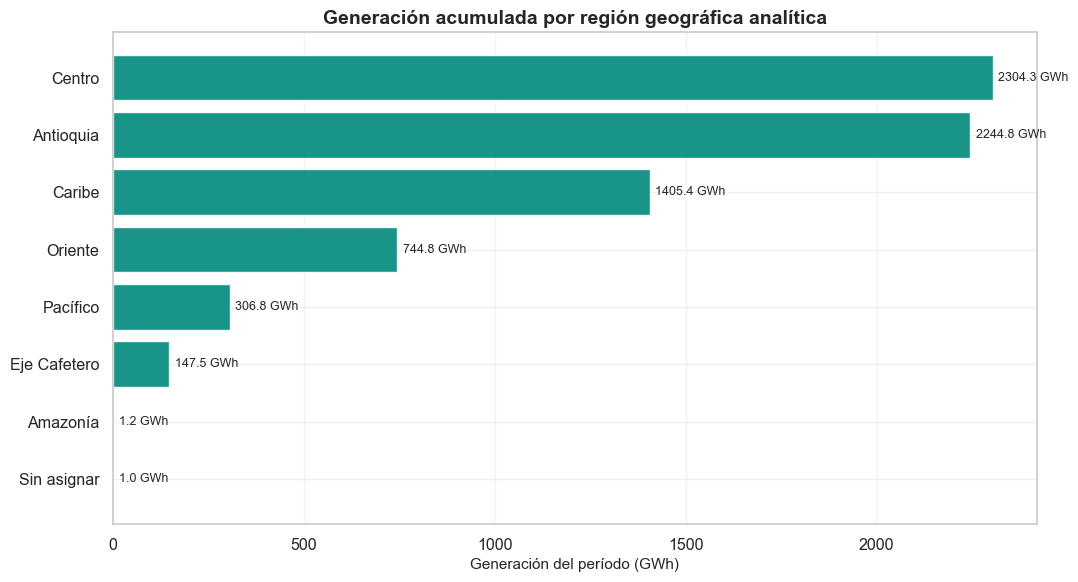

In [57]:
# Resultado base visible sin interacción.
fig_resumen_regiones = graficar_resumen_regiones(generacion_geografica)
if fig_resumen_regiones is not None:
    plt.show()


In [58]:
def crear_explorador_geografico(generacion: pd.DataFrame):
    """Crea los controles geográficos; devuelve ``None`` si no están disponibles."""
    if generacion.empty:
        print("⚠️ No hay generación geográfica para activar el explorador.")
        return None

    try:
        import ipywidgets as widgets
        from IPython.display import clear_output
    except ImportError:
        print("ℹ️ Instala ipywidgets para utilizar el selector geográfico.")
        return None

    selector_nivel = widgets.Dropdown(
        options=list(NIVELES_GEOGRAFICOS),
        value="Región geográfica",
        description="Nivel:",
    )
    selector_ambito = widgets.Dropdown(description="Ámbito:")
    selector_vista = widgets.ToggleButtons(
        options=["Heatmap", "Perfiles", "Ambas"],
        value="Heatmap",
        description="Vista:",
    )
    boton_graficar = widgets.Button(
        description="Generar figura",
        button_style="success",
        icon="globe",
    )
    salida = widgets.Output()

    def actualizar_ambitos(_=None) -> None:
        """Sincroniza el segundo selector con el nivel territorial elegido."""
        columna = NIVELES_GEOGRAFICOS[selector_nivel.value]
        valores = sorted(generacion[columna].dropna().unique().tolist())
        selector_ambito.options = ["Nacional", *valores]
        selector_ambito.value = "Nacional"

    def actualizar_figura(_=None) -> None:
        """Filtra una vez y reutiliza el resultado en las vistas solicitadas."""
        with salida:
            clear_output(wait=True)
            nivel = selector_nivel.value
            ambito = selector_ambito.value
            datos_filtrados = filtrar_generacion_geografica(
                generacion,
                nivel,
                ambito,
            )
            energia_gwh = pd.to_numeric(
                datos_filtrados["Generacion_kWh"],
                errors="coerce",
            ).sum() / 1e6
            print(
                f"{nivel}: {ambito} | "
                f"Plantas: {datos_filtrados['Codigo_Planta'].nunique():,} | "
                f"Generación: {energia_gwh:,.2f} GWh"
            )

            if selector_vista.value in ("Heatmap", "Ambas"):
                figura = graficar_heatmap_geografico(
                    datos_filtrados,
                    nivel,
                    ambito,
                )
                if figura is not None:
                    plt.show()
            if selector_vista.value in ("Perfiles", "Ambas"):
                figura = graficar_perfiles_geograficos(
                    datos_filtrados,
                    nivel,
                    ambito,
                )
                if figura is not None:
                    plt.show()

    selector_nivel.observe(actualizar_ambitos, names="value")
    boton_graficar.on_click(actualizar_figura)
    actualizar_ambitos()

    return widgets.VBox(
        [
            widgets.HBox(
                [
                    selector_nivel,
                    selector_ambito,
                    selector_vista,
                    boton_graficar,
                ]
            ),
            salida,
        ]
    )


explorador_geografico = crear_explorador_geografico(generacion_geografica)
if explorador_geografico is not None:
    display(explorador_geografico)


### 6.2 Heatmap: precio de bolsa hora × día

Visualización de la volatilidad intra-día del precio a lo largo del período completo. Un patrón vertical **rojo consistente en 18h–22h** confirma la ventana de arbitraje SAEB.

In [59]:
def graficar_heatmap_precio_dia_hora(
    fact_precio: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Heatmap Día × Hora del precio de bolsa (colormap divergente)."""
    if fact_precio.empty:
        print("⚠️  Faltan datos de precio para heatmap")
        return None

    df = fact_precio.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    pivot = df.pivot_table(index="Fecha", columns="Hora",
                           values="Precio_COP_kWh", aggfunc="mean")

    n_dias = pivot.shape[0]
    fig, ax = plt.subplots(figsize=(16, max(8, n_dias * 0.3)))
    sns.heatmap(pivot, cmap="RdYlGn_r", ax=ax,
                cbar_kws={"label": "Precio (COP/kWh)"},
                linewidths=0.15, linecolor="white")
    ax.set_title("Precio de bolsa — heatmap día × hora (verde=barato, rojo=caro)")
    ax.set_xlabel("Hora del día"); ax.set_ylabel("Fecha")
    # Formatear fechas del eje Y
    ax.set_yticklabels([d.strftime("%d %b") for d in pivot.index], rotation=0)
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_09_heatmap_precio_dia_hora_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig

💾 Figura guardada: fig_v2_09_heatmap_precio_dia_hora_20260510_20260607.png


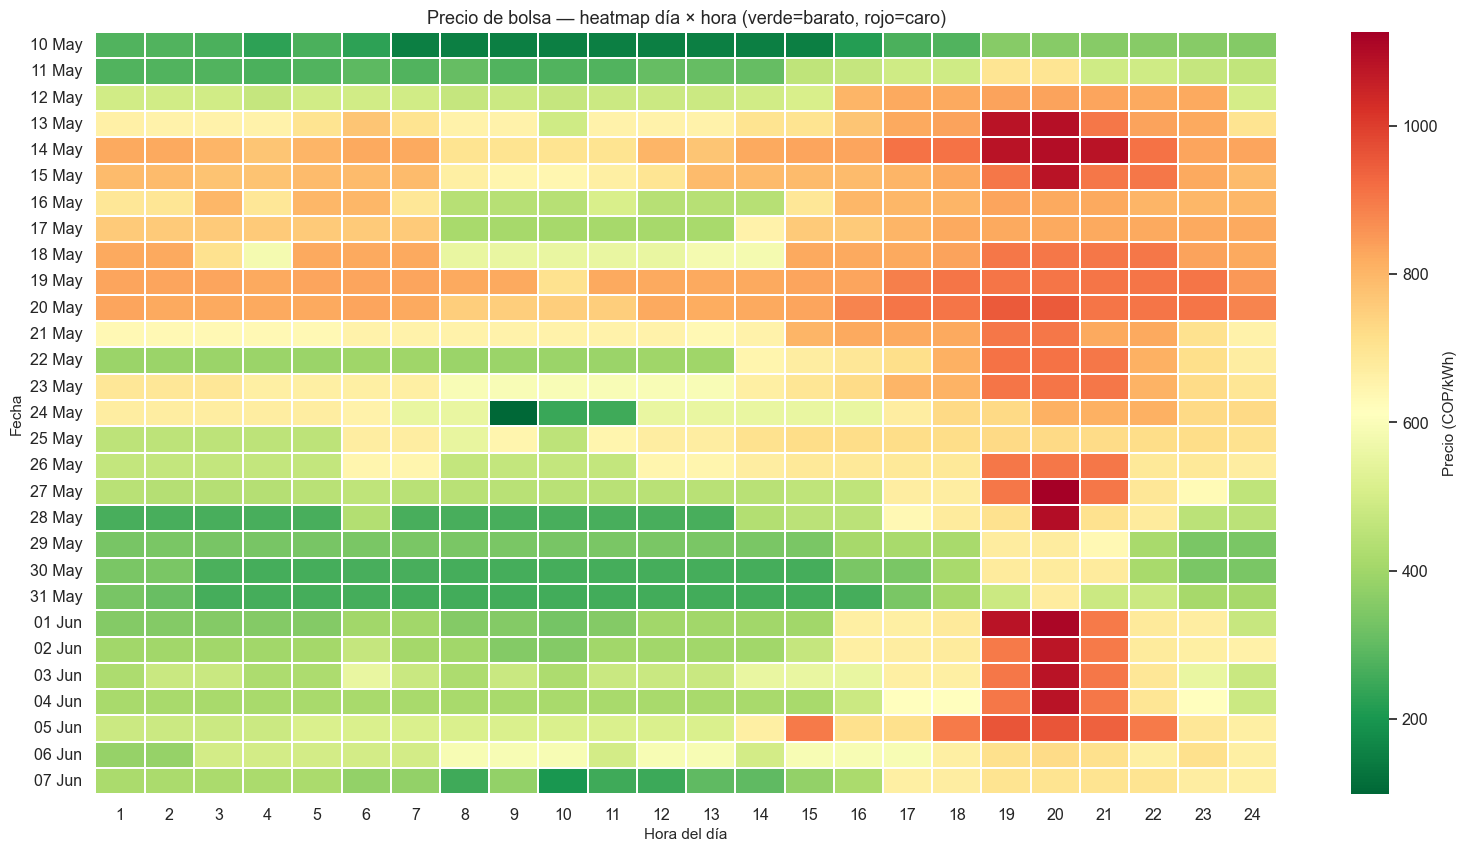

In [60]:
# Se genera la grafica de heatmap de precio por día y hora, si hay datos disponibles
fig = graficar_heatmap_precio_dia_hora(tablas.get("fact_precio", pd.DataFrame()))
if fig:
    plt.show()

### 6.3 Perfil solar: días laborables vs. fines de semana

Esta comparación permite explorar si el perfil horario de la generación solar presenta diferencias sistemáticas según el tipo de día. Aunque la producción fotovoltaica depende principalmente de la irradiancia y de las condiciones meteorológicas, la clasificación entre días laborables y fines de semana aporta contexto para estudiar su interacción con los patrones de consumo y la generación distribuida.

Los resultados deben interpretarse como una comparación descriptiva del período analizado, no como evidencia de que el tipo de día determina directamente la generación solar.

In [61]:
def graficar_perfil_solar_semana(
    gen_enriquecida: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Compara la generación solar total horaria por tipo de día."""
    requeridas = {"Tecnologia", "Fecha", "Hora", "Generacion_kWh"}
    if gen_enriquecida.empty or not requeridas.issubset(gen_enriquecida.columns):
        return None
    solar = gen_enriquecida[gen_enriquecida["Tecnologia"].eq("SOLAR")].copy()
    if solar.empty:
        print("ℹ️  No hay generación solar en el período — se omite el gráfico.")
        return None
    solar["Fecha"] = pd.to_datetime(solar["Fecha"])
    solar["Tipo_Dia"] = np.where(solar["Fecha"].dt.dayofweek >= 5, "Fin de semana", "Laborable")

    solar_dia_h = (
        solar.groupby(["Tipo_Dia", "Fecha", "Hora"], as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
    )
    perfil = (
        solar_dia_h.groupby(["Tipo_Dia", "Hora"])["Generacion_kWh"]
        .mean().div(1e6)
        .reset_index(name="Gen_GWh_prom")
    )

    fig, ax = plt.subplots(figsize=(12, 4.5))
    for tipo, color in [("Laborable", "#1976D2"), ("Fin de semana", "#F57C00")]:
        sub = perfil[perfil["Tipo_Dia"] == tipo]
        ax.plot(sub["Hora"], sub["Gen_GWh_prom"], marker="o", linewidth=2,
                color=color, label=tipo)
    ax.set_title("Perfil horario de generación solar total: laborables vs fines de semana")
    ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
    ax.set_ylabel("Generación solar promedio (GWh/h)")
    ax.set_xticks(range(1, 25))
    ax.legend()
    plt.tight_layout()

    if guardar:
        ruta = FIG_DIR / f"fig_v2_10_perfil_solar_semana_{ETIQUETA_PERIODO}.png"
        fig.savefig(ruta, dpi=150, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


💾 Figura guardada: fig_v2_10_perfil_solar_semana_20260510_20260607.png


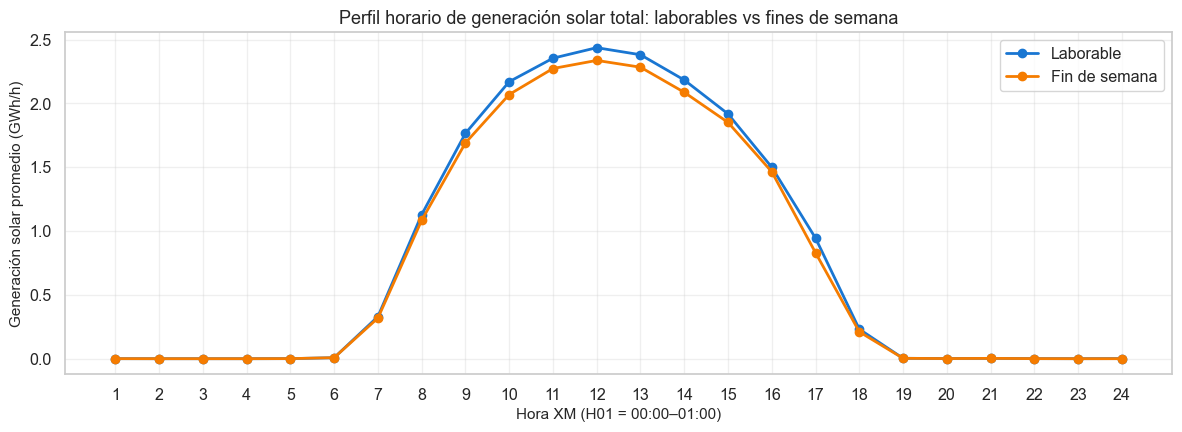

In [62]:
# Se genera la grafica de perfil solar por tipo de día, si hay datos disponibles
fig = graficar_perfil_solar_semana(tablas.get("gen_enriquecida", pd.DataFrame()))
if fig:
    plt.show()

#### 6.3.1 Solar y demanda por tipo de día

La generación solar y la demanda se presentan en paneles separados para
conservar escalas legibles. La comparación permite estudiar cómo cambia la
coincidencia temporal entre el recurso solar y el consumo del SIN durante días
laborables y fines de semana.

💾 Figura guardada: fig_v2_10b_perfil_solar_demanda_tipo_dia_20260510_20260607.png


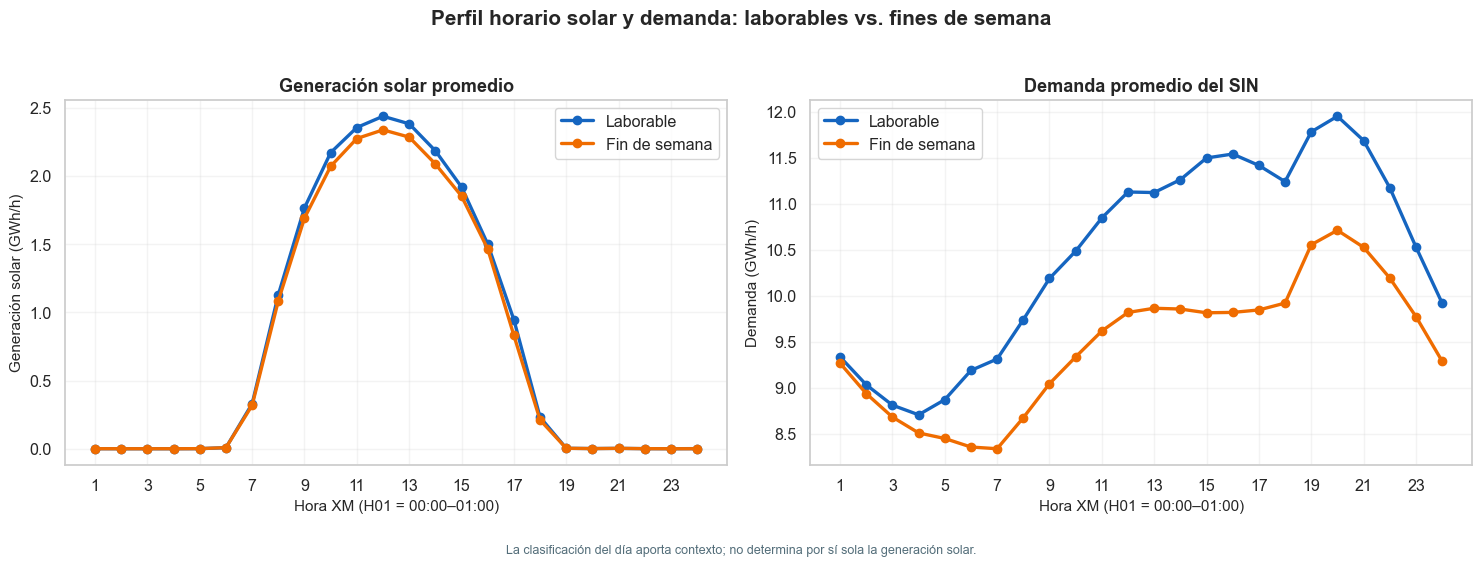

In [63]:
def graficar_perfil_solar_demanda_tipo_dia(
    gen_enriquecida: pd.DataFrame,
    fact_demanda: pd.DataFrame,
    guardar: bool = True,
) -> plt.Figure | None:
    """Compara solar y demanda en paneles separados por tipo de día."""
    req_solar = {"Tecnologia", "Fecha", "Hora", "Generacion_kWh"}
    req_demanda = {"Fecha", "Hora", "Demanda_kWh"}
    if (
        gen_enriquecida.empty or fact_demanda.empty
        or not req_solar.issubset(gen_enriquecida.columns)
        or not req_demanda.issubset(fact_demanda.columns)
    ):
        print("⚠️  Se requieren generación solar y demanda para esta comparación.")
        return None

    solar = gen_enriquecida[gen_enriquecida["Tecnologia"].eq("SOLAR")].copy()
    if solar.empty:
        return None
    solar["Fecha"] = pd.to_datetime(solar["Fecha"])
    solar["Tipo_Dia"] = np.where(
        solar["Fecha"].dt.dayofweek >= 5, "Fin de semana", "Laborable"
    )
    solar_dia = (
        solar.groupby(["Tipo_Dia", "Fecha", "Hora"], as_index=False)["Generacion_kWh"]
        .sum(min_count=1)
    )
    perfil_solar = (
        solar_dia.groupby(["Tipo_Dia", "Hora"], as_index=False)["Generacion_kWh"]
        .mean()
    )
    perfil_solar["Valor_GWh"] = perfil_solar["Generacion_kWh"] / 1e6

    demanda = fact_demanda.copy()
    demanda["Fecha"] = pd.to_datetime(demanda["Fecha"])
    demanda["Tipo_Dia"] = np.where(
        demanda["Fecha"].dt.dayofweek >= 5, "Fin de semana", "Laborable"
    )
    demanda_dia = (
        demanda.groupby(["Tipo_Dia", "Fecha", "Hora"], as_index=False)["Demanda_kWh"]
        .sum(min_count=1)
    )
    perfil_demanda = (
        demanda_dia.groupby(["Tipo_Dia", "Hora"], as_index=False)["Demanda_kWh"]
        .mean()
    )
    perfil_demanda["Valor_GWh"] = perfil_demanda["Demanda_kWh"] / 1e6

    colores_dia = {"Laborable": "#1565C0", "Fin de semana": "#EF6C00"}
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)
    for tipo_dia, color in colores_dia.items():
        solar_tipo = perfil_solar[perfil_solar["Tipo_Dia"].eq(tipo_dia)]
        demanda_tipo = perfil_demanda[perfil_demanda["Tipo_Dia"].eq(tipo_dia)]
        axes[0].plot(
            solar_tipo["Hora"], solar_tipo["Valor_GWh"],
            marker="o", linewidth=2.4, color=color, label=tipo_dia,
        )
        axes[1].plot(
            demanda_tipo["Hora"], demanda_tipo["Valor_GWh"],
            marker="o", linewidth=2.4, color=color, label=tipo_dia,
        )

    axes[0].set_title("Generación solar promedio", fontweight="bold")
    axes[0].set_ylabel("Generación solar (GWh/h)")
    axes[1].set_title("Demanda promedio del SIN", fontweight="bold")
    axes[1].set_ylabel("Demanda (GWh/h)")
    for ax in axes:
        ax.set_xlabel("Hora XM (H01 = 00:00–01:00)")
        ax.set_xticks(range(1, 25, 2))
        ax.legend()
        ax.grid(alpha=0.22)
    fig.suptitle(
        "Perfil horario solar y demanda: laborables vs. fines de semana",
        fontsize=15, fontweight="bold",
    )
    fig.text(
        0.5, -0.01,
        "La clasificación del día aporta contexto; no determina por sí sola la generación solar.",
        ha="center", color="#546E7A", fontsize=9,
    )
    plt.tight_layout(rect=(0, 0.03, 1, 0.96))
    if guardar:
        ruta = FIG_DIR / (
            f"fig_v2_10b_perfil_solar_demanda_tipo_dia_{ETIQUETA_PERIODO}.png"
        )
        fig.savefig(ruta, dpi=160, bbox_inches="tight")
        print(f"💾 Figura guardada: {ruta.name}")
    return fig


fig_solar_demanda = graficar_perfil_solar_demanda_tipo_dia(
    tablas.get("gen_enriquecida", pd.DataFrame()),
    tablas.get("fact_demanda", pd.DataFrame()),
)
if fig_solar_demanda:
    plt.show()

---
## 📋 Sección 7 — Resumen Ejecutivo y Preparación para v2.5 (SAEB)

### 7.1 Exportar tablas procesadas

Todas las tablas analíticas se guardan en `data/processed/` con estampa `YYYYMMDD_YYYYMMDD` (rango del período) para que v2.5 las consuma.

In [64]:
# ── Guardar outputs en data/processed/ ────────────────────────────────────────
tablas_a_exportar = {
    "fact_generacion":     tablas.get("fact_generacion",     pd.DataFrame()),
    "fact_demanda":        tablas.get("fact_demanda",        pd.DataFrame()),
    "fact_precio":         tablas.get("fact_precio",         pd.DataFrame()),
    "fact_embalses":       tablas.get("fact_embalses",       pd.DataFrame()),
    "fact_aportes":        tablas.get("fact_aportes",        pd.DataFrame()),
    "fact_precio_escasez": tablas.get("fact_precio_escasez", pd.DataFrame()),
    "gen_enriquecida":     tablas.get("gen_enriquecida",     pd.DataFrame()),
    "sistema_h":           tablas.get("sistema_h",           pd.DataFrame()),
    "resumen_diario":      tablas.get("resumen_diario",      pd.DataFrame()),
}

print(f"💾 Exportando tablas procesadas (etiqueta: {ETIQUETA_PERIODO})...\n")

for nombre, df in tablas_a_exportar.items():
    if df.empty:
        print(f"  ⏭️   {nombre:20s} — vacío, se omite")
        continue
    ruta = PROCESSED_DIR / f"{nombre}_{ETIQUETA_PERIODO}.csv"
    df.to_csv(ruta, index=False)
    print(f"  ✅ {nombre:20s} → {ruta.name} ({df.shape[0]:>7,} filas)")

print(f"\n✅ Todos los outputs guardados en {PROCESSED_DIR}")

💾 Exportando tablas procesadas (etiqueta: 20260510_20260607)...

  ✅ fact_generacion      → fact_generacion_20260510_20260607.csv (318,624 filas)
  ✅ fact_demanda         → fact_demanda_20260510_20260607.csv (    696 filas)
  ✅ fact_precio          → fact_precio_20260510_20260607.csv (    696 filas)
  ✅ fact_embalses        → fact_embalses_20260510_20260607.csv (     29 filas)
  ✅ fact_aportes         → fact_aportes_20260510_20260607.csv (     29 filas)
  ✅ fact_precio_escasez  → fact_precio_escasez_20260510_20260607.csv (     29 filas)
  ✅ gen_enriquecida      → gen_enriquecida_20260510_20260607.csv (318,624 filas)
  ✅ sistema_h            → sistema_h_20260510_20260607.csv (    696 filas)
  ✅ resumen_diario       → resumen_diario_20260510_20260607.csv (     29 filas)

✅ Todos los outputs guardados en G:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\processed


### 7.2 Resumen cuantitativo reproducible

La celda siguiente genera hallazgos desde los datos ejecutados. Si una métrica no
está disponible, se reporta explícitamente en vez de completar un valor manual o
inferirlo. Los resultados son descriptivos del período común analizado.

In [65]:
def construir_hallazgos(
    resumen: pd.DataFrame,
    sistema: pd.DataFrame,
    kpis_precio: dict,
) -> pd.DataFrame:
    filas = []

    def agregar(indicador: str, valor, unidad: str, interpretacion: str) -> None:
        filas.append({"Indicador": indicador, "Valor": valor, "Unidad": unidad,
                      "Interpretación": interpretacion})

    if "Balance_GWh" in resumen:
        serie = resumen["Balance_GWh"].dropna()
        if not serie.empty:
            agregar("Gap generación-demanda promedio", round(serie.mean(), 2), "GWh/día",
                    "Diagnóstico de consistencia; no equivale por sí solo a exportación.")
    if {"Hora", "Gap_Gen_Dem_kWh"}.issubset(sistema.columns):
        perfil_gap = sistema.groupby("Hora")["Gap_Gen_Dem_kWh"].mean()
        if not perfil_gap.empty:
            agregar("Hora XM con gap promedio mínimo", int(perfil_gap.idxmin()), "H01–H24",
                    "H01 representa 00:00–01:00.")
    if {"Precio_Prom_COP", "Nivel_Embalses_Pct"}.issubset(resumen.columns):
        r = resumen[["Precio_Prom_COP", "Nivel_Embalses_Pct"]].corr().iloc[0, 1]
        agregar("Correlación precio-embalses", round(r, 3), "Pearson r",
                "Asociación del período; no prueba causalidad.")
    if {"Precio_Prom_COP", "Participacion_Termica_pct"}.issubset(resumen.columns):
        r = resumen[["Precio_Prom_COP", "Participacion_Termica_pct"]].corr().iloc[0, 1]
        agregar("Correlación precio-participación térmica", round(r, 3), "Pearson r",
                "Asociación del período; sensible a variables omitidas.")
    if "Nivel_Embalses_Pct" in resumen:
        nivel = resumen["Nivel_Embalses_Pct"].dropna()
        if not nivel.empty:
            agregar("Nivel mínimo de embalses", round(nivel.min(), 2), "%",
                    "Comparar con contexto operativo oficial del período.")
            agregar("Días bajo banda exploratoria de 60%", int((nivel < UMBRAL_EMBALSES_ALERTA).sum()), "días",
                    "Umbral gráfico, no alerta regulatoria.")
    if kpis_precio:
        agregar("Spread bruto pico-valle", round(kpis_precio["spread_bruto_COP_kWh"], 2), "COP/kWh",
                "Input exploratorio para v2.5.")
        agregar("Spread ajustado por eficiencia", round(kpis_precio["spread_ajustado_eficiencia_COP_kWh"], 2), "COP/kWh",
                "Aún no incluye degradación, CAPEX, OPEX ni restricciones operativas.")

    if not filas:
        filas.append({"Indicador": "Datos v2 no disponibles", "Valor": np.nan, "Unidad": "—",
                      "Interpretación": "Cargue demanda, precio, embalses y aportes para completar el resumen."})
    return pd.DataFrame(filas)


hallazgos_v2 = construir_hallazgos(
    tablas.get("resumen_diario", pd.DataFrame()),
    tablas.get("sistema_h", pd.DataFrame()),
    globals().get("kpis_saeb", {}),
)
display(hallazgos_v2)
ruta_hallazgos = PROCESSED_DIR / f"hallazgos_v2_{ETIQUETA_PERIODO}.csv"
hallazgos_v2.to_csv(ruta_hallazgos, index=False)
print(f"💾 Hallazgos exportados: {ruta_hallazgos.name}")

,Indicador,Valor,Unidad,Interpretación
0,Gap generación-demanda promedio,3.310,GWh/día,Diagnóstico de consistencia; no equivale por s...
1,Hora XM con gap promedio mínimo,10.000,H01–H24,H01 representa 00:00–01:00.
2,Correlación precio-embalses,-0.443,Pearson r,Asociación del período; no prueba causalidad.
3,Correlación precio-participación térmica,0.793,Pearson r,Asociación del período; sensible a variables o...
4,Nivel mínimo de embalses,64.460,%,Comparar con contexto operativo oficial del pe...
5,Días bajo banda exploratoria de 60%,0.000,días,"Umbral gráfico, no alerta regulatoria."
6,Spread bruto pico-valle,265.170,COP/kWh,Input exploratorio para v2.5.
7,Spread ajustado por eficiencia,186.650,COP/kWh,"Aún no incluye degradación, CAPEX, OPEX ni res..."


💾 Hallazgos exportados: hallazgos_v2_20260510_20260607.csv


### 7.3 Preparación para v2.5 — SAEB (Resolución CREG 101 113 de 2026)

La resolución vigente define reglas de instalación, operación y aspectos
comerciales de los SAEB en el SIN. Este notebook solo prepara datos de mercado;
no reemplaza el modelado operativo ni el análisis regulatorio/económico de v2.5.

| Dato de v2 | Archivo consumible | Uso posterior |
|:--|:--|:--|
| Precio horario | `fact_precio_*.csv` | Optimización de carga/descarga |
| Demanda horaria | `fact_demanda_*.csv` | Contexto de ventanas operativas |
| Embalses | `fact_embalses_*.csv` | Escenarios de estrés hídrico |
| Participación térmica | `resumen_diario_*.csv` | Contexto de emisiones, con supuestos explícitos |
| Hallazgos | `hallazgos_v2_*.csv` | Trazabilidad de KPIs del período |

Fuentes oficiales consultadas:

- [Resolución CREG 101 113 de 2026](https://gestornormativo.creg.gov.co/gestor/entorno/docs/resolucion_creg_101-113_2026.htm)
- [XM — precio de bolsa y precio de escasez](https://www.xm.com.co/transacciones/cargo-por-confiabilidad/precio-de-bolsa-y-escasez)

---

### 7.4 Estado del roadmap

| Versión | Enfoque | Estado |
|:--|:--|:--|
| v1 | ETL + EDA de generación | Completada |
| v2 | Series, balance, precio e hidrología | Lista para validar con las seis métricas |
| v2.5 | Simulación y caso SAEB | Siguiente entrega |
| v3 | Capacidad, emisiones y factor de planta | Planeada |
| v4 | Dashboard Streamlit | Planeada |
| v5 | Predicción y desviaciones | Planeada |